In [1]:
import sys, os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import roc_curve, roc_auc_score
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
os.chdir("/data/projects/liquid_biopsy/Projects/cfDNA/cfDNA/")
sys.path.insert(0, "scripts/analysis")

from helpers import (
    FEATURE_NAMES, RENAME, RENAME_INV, ZHOU_SCORES,
    NEW_FEATURES, CANCER_RENAME, CANCER_RENAME_INV,
    load_roc_data, bootstrap_auc_ci, sens_at_spec,
    build_auc_table, build_sensitivity_table,
)
print(NEW_FEATURES)
palette = sns.color_palette("tab20", len(FEATURE_NAMES))
DIFF_COLORS = {f: palette[i] for i, f in enumerate(FEATURE_NAMES)}
for i in FEATURE_NAMES:
    DIFF_COLORS[RENAME.get(i, i)] = DIFF_COLORS[i]

def feat_color(name):
    return DIFF_COLORS.get(name, DIFF_COLORS.get(RENAME_INV.get(name, name), '#888888'))

def is_new_color(name):
    return '#d62728' if name in NEW_FEATURES else '#1f77b4'


{'eoEDM', 'iEDM', 'eEDM', 'ocEDM'}


## Hyperparameter Tuning

In [2]:
ht_dir = "data/model_results/hyperparam_tuning/"

rbf_mapq0 = pd.read_csv(ht_dir + "rbf_mapq0_1x10.csv")
rbf_mapq15 = pd.read_csv(ht_dir + "rbf_mapq15_1x10.csv")
rbf_mapq30 = pd.read_csv(ht_dir + "rbf_mapq30_1x10.csv")
rbf_mapq45 = pd.read_csv(ht_dir + "rbf_mapq45_1x10.csv")
linear_nopca = pd.read_csv(ht_dir + "linear_nopca_mapq30_1x10.csv")
linear_pca50 = pd.read_csv(ht_dir + "linear_pca50_mapq30_1x10.csv")
linear_pca100 = pd.read_csv(ht_dir + "linear_pca100_mapq30_1x10.csv")
linear_pca150 = pd.read_csv(ht_dir + "linear_pca150_mapq30_1x10.csv")
linear_pca200 = pd.read_csv(ht_dir + "linear_pca200_mapq30_1x10.csv")
linear_pca150_gc_1x10 = pd.read_csv(ht_dir + "linear_pca150_gc_mapq30_1x10.csv")
linear_pca150_10x10 = pd.read_csv(ht_dir + "linear_pca150_mapq30_10x10.csv")
linear_pca150_gc_10x10 = pd.read_csv(ht_dir + "linear_pca150_gc_mapq30_10x10.csv")

zhou_ref = pd.DataFrame(list(ZHOU_SCORES.items()), columns=['feature', 'zhou'])

def merge_configs(configs):
    df = pd.DataFrame(FEATURE_NAMES, columns=['feature'])
    for col, dfm in configs.items():
        df = df.merge(dfm[['feature', 'auc']].rename(columns={'auc': col}), on='feature', how='left')
    return df.merge(zhou_ref, on='feature', how='left')

mapq_auc = merge_configs({'mapq0': rbf_mapq0, 'mapq15': rbf_mapq15, 'mapq30': rbf_mapq30, 'mapq45': rbf_mapq45})
kernel_auc = merge_configs({'rbf': rbf_mapq30, 'linear': linear_nopca})
pca_auc = merge_configs({'pca50': linear_pca50, 'pca100': linear_pca100, 'pca150': linear_pca150, 'pca200': linear_pca200, 'no_pca': linear_nopca})
gc_1x10_auc = merge_configs({'gc_false': linear_pca150, 'gc_true': linear_pca150_gc_1x10})
gc_10x10_auc = merge_configs({'gc_false': linear_pca150_10x10, 'gc_true': linear_pca150_gc_10x10})


### MAPQ Filtering Threshold

/tmp/ipykernel_1528215/2029155428.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


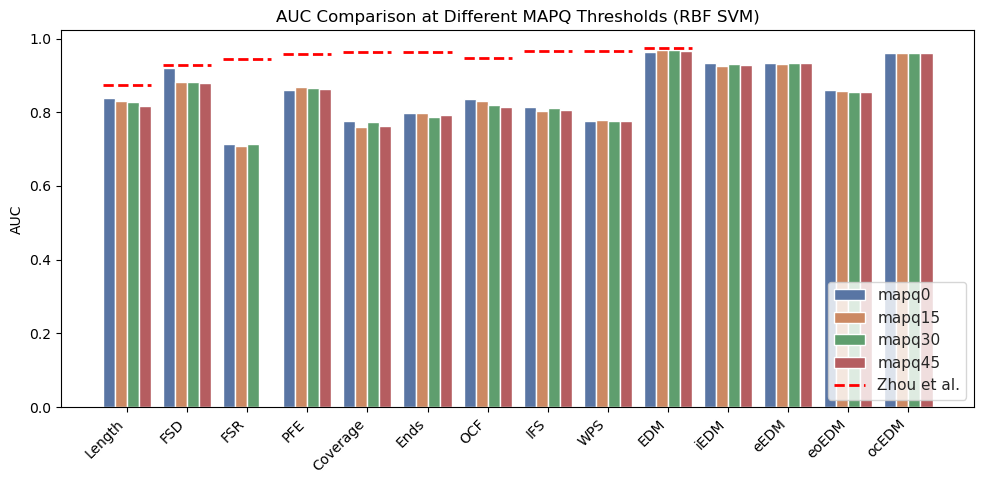

/tmp/ipykernel_1528215/2029155428.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


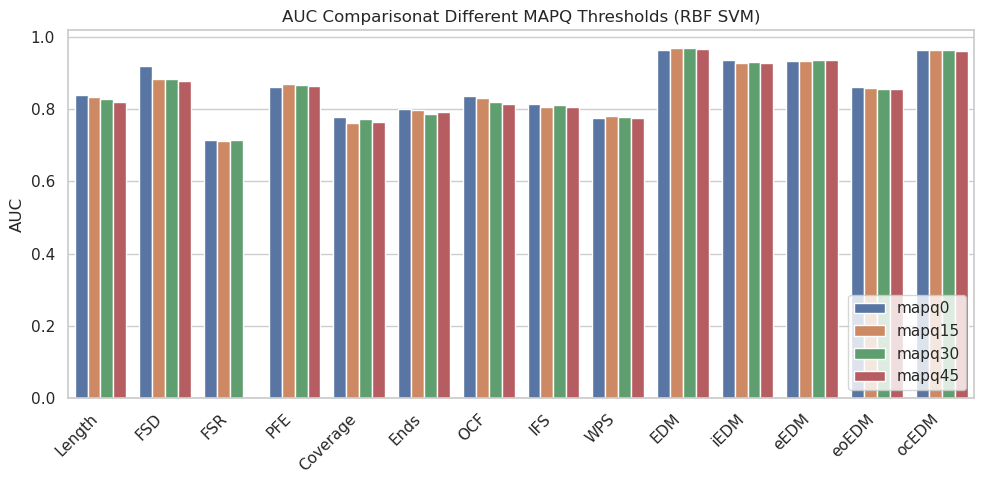

In [3]:
auc_df_melted = mapq_auc.melt(id_vars='feature', value_vars=['mapq0', 'mapq15', 'mapq30', 'mapq45'], var_name='mapq', value_name='AUC')
auc_df_melted['feature'] = auc_df_melted['feature'].replace(RENAME)

fig, ax = plt.subplots(figsize=(10, 5))
sns.set_theme(style='whitegrid')
sns.barplot(data=auc_df_melted, x='feature', y='AUC', hue='mapq', ax=ax)
for i, zhou_val in enumerate(mapq_auc['zhou']):
    ax.hlines(zhou_val, i - 0.4, i + 0.4, colors='red', linewidth=2, linestyles='--',
              label='Zhou et al.' if i == 0 else '')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_xlabel('')
ax.set_title('AUC Comparison at Different MAPQ Thresholds (RBF SVM)')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig("scripts/analysis/figures/01_mapq_zhou.png")
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=auc_df_melted, x='feature', y='AUC', hue='mapq', ax=ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_xlabel('')
ax.set_title('AUC Comparisonat Different MAPQ Thresholds (RBF SVM)')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig("scripts/analysis/figures/01_mapq.png")
plt.show()


/tmp/ipykernel_1528215/2209236989.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


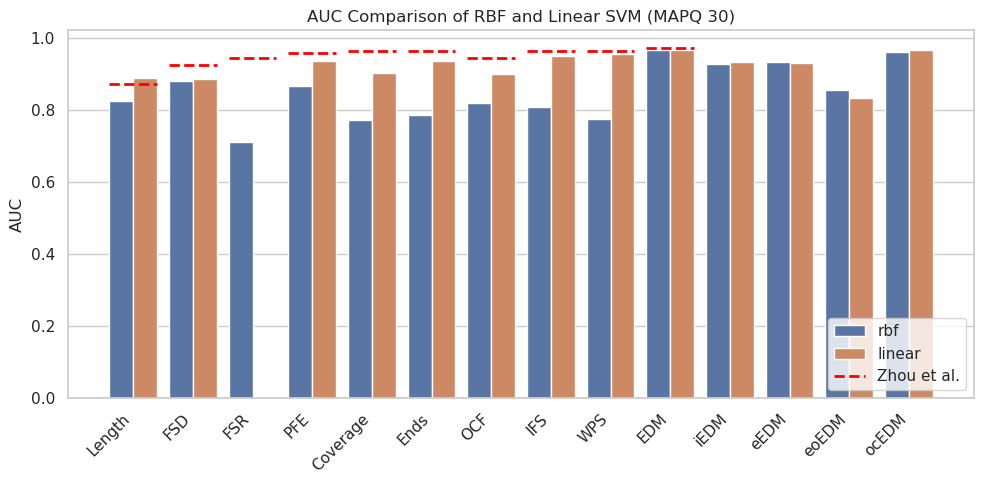

/tmp/ipykernel_1528215/2209236989.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


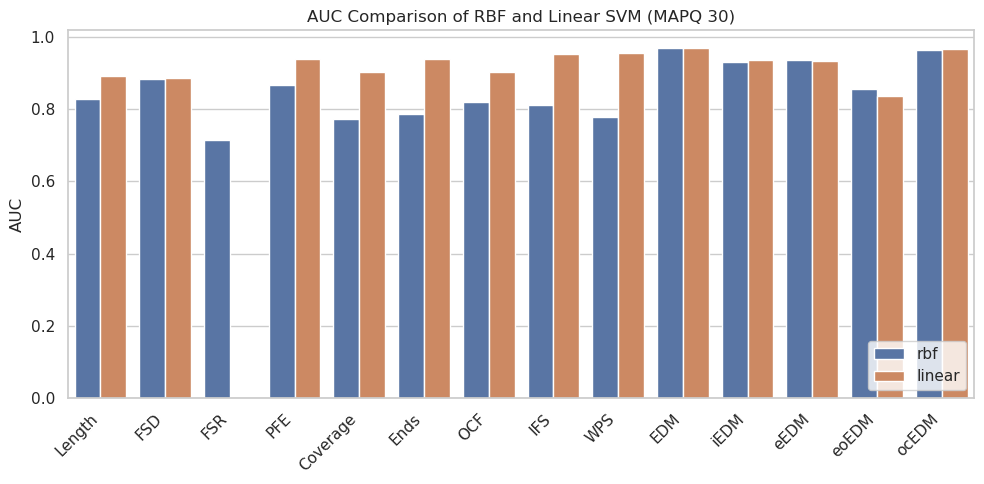

In [4]:
auc_df_melted = kernel_auc.melt(id_vars='feature', value_vars=['rbf', 'linear'], var_name='Model', value_name='AUC')
auc_df_melted['feature'] = auc_df_melted['feature'].replace(RENAME)

fig, ax = plt.subplots(figsize=(10, 5))
sns.set_theme(style='whitegrid')
sns.barplot(data=auc_df_melted, x='feature', y='AUC', hue='Model', ax=ax)
for i, zhou_val in enumerate(kernel_auc['zhou']):
    ax.hlines(zhou_val, i - 0.4, i + 0.4, colors='red', linewidth=2, linestyles='--',
              label='Zhou et al.' if i == 0 else '')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_xlabel('')
ax.set_title('AUC Comparison of RBF and Linear SVM (MAPQ 30)')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig("scripts/analysis/figures/02_kernel_zhou.png")
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=auc_df_melted, x='feature', y='AUC', hue='Model', ax=ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_xlabel('')
ax.set_title('AUC Comparison of RBF and Linear SVM (MAPQ 30)')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig("scripts/analysis/figures/02_kernel.png")
plt.show()


## PCA

/tmp/ipykernel_1528215/1462760973.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


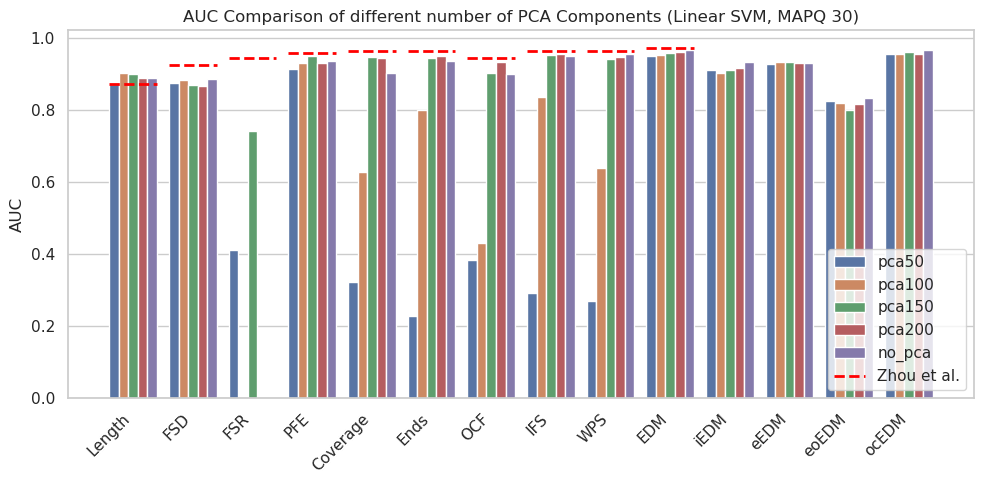

/tmp/ipykernel_1528215/1462760973.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


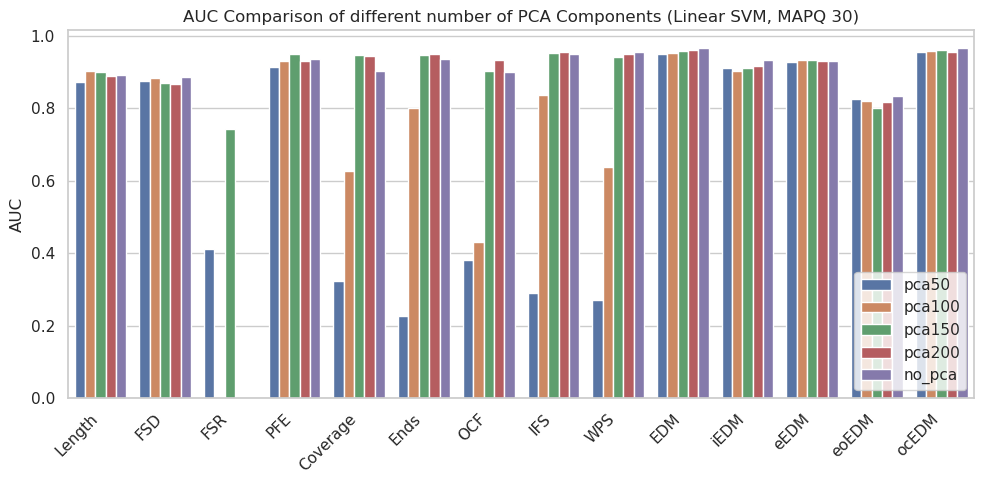

In [5]:
auc_df_melted = pca_auc.melt(id_vars='feature', value_vars=['pca50', 'pca100', 'pca150', 'pca200', 'no_pca'], var_name='Model', value_name='AUC')
auc_df_melted['feature'] = auc_df_melted['feature'].replace(RENAME)

fig, ax = plt.subplots(figsize=(10, 5))
sns.set_theme(style='whitegrid')
sns.barplot(data=auc_df_melted, x='feature', y='AUC', hue='Model', ax=ax)
for i, zhou_val in enumerate(pca_auc['zhou']):
    ax.hlines(zhou_val, i - 0.4, i + 0.4, colors='red', linewidth=2, linestyles='--',
              label='Zhou et al.' if i == 0 else '')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_xlabel('')
ax.set_title('AUC Comparison of different number of PCA Components (Linear SVM, MAPQ 30)')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig("scripts/analysis/figures/03_pca_zhou.png")
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=auc_df_melted, x='feature', y='AUC', hue='Model', ax=ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_xlabel('')
ax.set_title('AUC Comparison of different number of PCA Components (Linear SVM, MAPQ 30)')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig("scripts/analysis/figures/03_pca.png")
plt.show()


## GC Correction

In [6]:
os.makedirs("scripts/analysis/tables", exist_ok=True)
gc_features = ['pfe', 'coverage', 'ends', 'ocf', 'ifs', 'wps']

table_zhou = gc_1x10_auc[gc_1x10_auc['feature'].isin(gc_features)][['feature', 'gc_false', 'gc_true', 'zhou']].round(4).set_index('feature')
table_zhou.to_csv("scripts/analysis/tables/04_gc_1x10_zhou.csv")
display(table_zhou)

table = gc_1x10_auc[gc_1x10_auc['feature'].isin(gc_features)][['feature', 'gc_false', 'gc_true']].round(4).set_index('feature')
table.to_csv("scripts/analysis/tables/04_gc_1x10.csv")
display(table)


,gc_false,gc_true,zhou
feature,,,
pfe,0.9507,0.9502,0.9579
coverage,0.9476,0.9160,0.9638
ends,0.9465,0.9390,0.9639
ocf,0.9028,0.9143,0.9467
ifs,0.9526,0.9404,0.9653
wps,0.9423,0.9555,0.9658


,gc_false,gc_true
feature,,
pfe,0.9507,0.9502
coverage,0.9476,0.9160
ends,0.9465,0.9390
ocf,0.9028,0.9143
ifs,0.9526,0.9404
wps,0.9423,0.9555


/tmp/ipykernel_1528215/1158787379.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


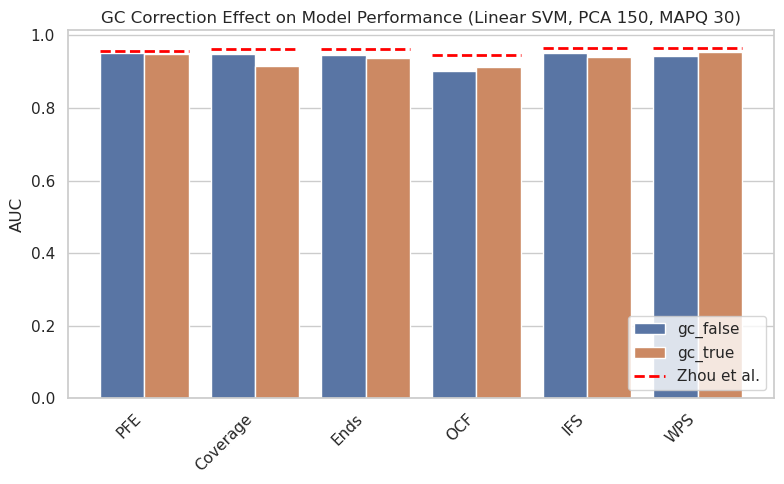

/tmp/ipykernel_1528215/1158787379.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


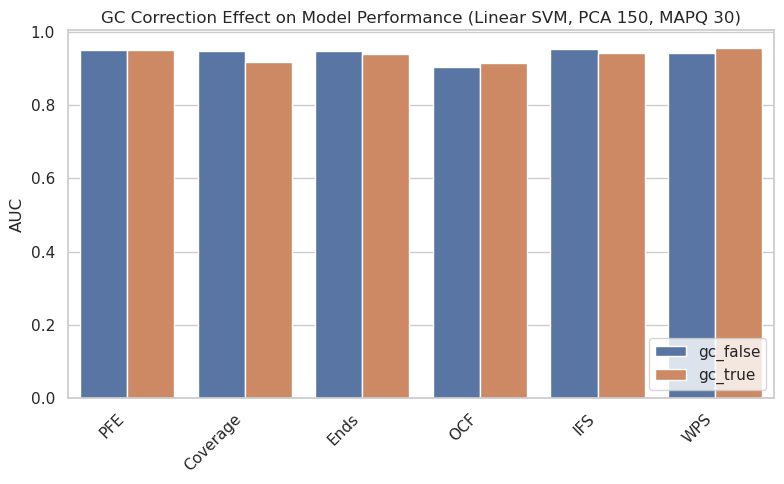

In [7]:
gc_features = ['pfe', 'coverage', 'ends', 'ocf', 'ifs', 'wps']
auc_df_melted = gc_1x10_auc[gc_1x10_auc['feature'].isin(gc_features)].melt(
    id_vars='feature', value_vars=['gc_false', 'gc_true'], var_name='Model', value_name='AUC')
auc_df_melted['feature'] = auc_df_melted['feature'].replace(RENAME)

fig, ax = plt.subplots(figsize=(8, 5))
sns.set_theme(style='whitegrid')
sns.barplot(data=auc_df_melted, x='feature', y='AUC', hue='Model', ax=ax)
for i, (idx, row) in enumerate(gc_1x10_auc[gc_1x10_auc['feature'].isin(gc_features)].iterrows()):
    ax.hlines(row['zhou'], i - 0.4, i + 0.4, colors='red', linewidth=2, linestyles='--',
              label='Zhou et al.' if i == 0 else '')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_xlabel('')
ax.set_title('GC Correction Effect on Model Performance (Linear SVM, PCA 150, MAPQ 30)')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig("scripts/analysis/figures/04_gc_correction_zhou.png")
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=auc_df_melted, x='feature', y='AUC', hue='Model', ax=ax)

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_xlabel('')
ax.set_title('GC Correction Effect on Model Performance (Linear SVM, PCA 150, MAPQ 30)')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig("scripts/analysis/figures/04_gc_correction.png")
plt.show()


In [8]:
gc_features = ['pfe', 'coverage', 'ends', 'ocf', 'ifs', 'wps']

table_zhou = gc_1x10_auc[gc_1x10_auc['feature'].isin(gc_features)].set_index('feature')[['gc_true', 'zhou']].round(4).rename(
    columns={'gc_true': 'linear_pca150_gc_1x10', 'zhou': 'zhou_et_al'})
table_zhou.to_csv("scripts/analysis/tables/04_gc_1x10_summary_zhou.csv")
display(table_zhou)

table = gc_1x10_auc[gc_1x10_auc['feature'].isin(gc_features)].set_index('feature')[['gc_true']].round(4).rename(
    columns={'gc_true': 'linear_pca150_gc_1x10'})
table.to_csv("scripts/analysis/tables/04_gc_1x10_summary.csv")
display(table)


,linear_pca150_gc_1x10,zhou_et_al
feature,,
pfe,0.9502,0.9579
coverage,0.9160,0.9638
ends,0.9390,0.9639
ocf,0.9143,0.9467
ifs,0.9404,0.9653
wps,0.9555,0.9658


,linear_pca150_gc_1x10
feature,
pfe,0.9502
coverage,0.9160
ends,0.9390
ocf,0.9143
ifs,0.9404
wps,0.9555


In [9]:
gc_features = ['pfe', 'coverage', 'ends', 'ocf', 'ifs', 'wps']

table_zhou = gc_10x10_auc[gc_10x10_auc['feature'].isin(gc_features)][['feature', 'gc_false', 'gc_true', 'zhou']].round(4).set_index('feature')
table_zhou.to_csv("scripts/analysis/tables/05_gc_10x10_zhou.csv")
display(table_zhou)

table = gc_10x10_auc[gc_10x10_auc['feature'].isin(gc_features)][['feature', 'gc_false', 'gc_true']].round(4).set_index('feature')
table.to_csv("scripts/analysis/tables/05_gc_10x10.csv")
display(table)


,gc_false,gc_true,zhou
feature,,,
pfe,0.9427,0.9540,0.9579
coverage,0.9566,0.9506,0.9638
ends,0.9606,0.9577,0.9639
ocf,0.9345,0.9156,0.9467
ifs,0.9610,0.9604,0.9653
wps,0.9517,0.9576,0.9658


,gc_false,gc_true
feature,,
pfe,0.9427,0.9540
coverage,0.9566,0.9506
ends,0.9606,0.9577
ocf,0.9345,0.9156
ifs,0.9610,0.9604
wps,0.9517,0.9576


/tmp/ipykernel_1528215/2266200701.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


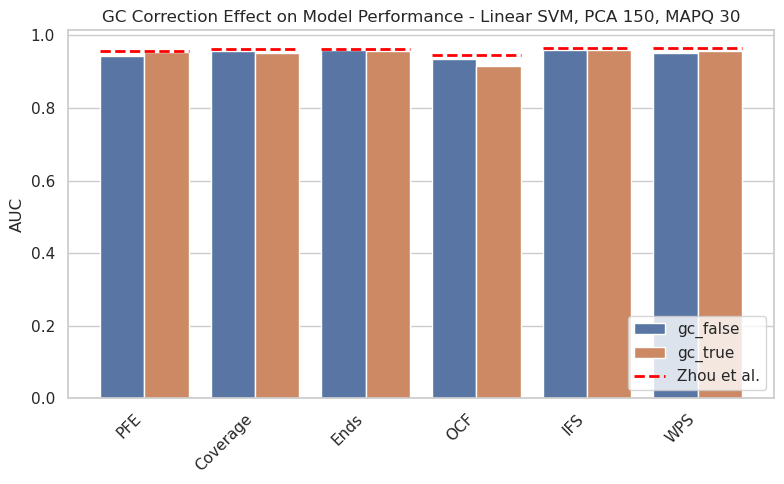

/tmp/ipykernel_1528215/2266200701.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


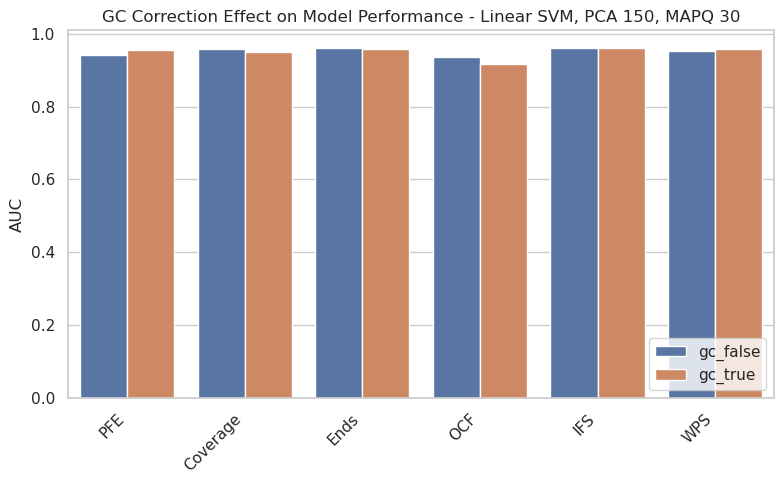

In [10]:
gc_features = ['pfe', 'coverage', 'ends', 'ocf', 'ifs', 'wps']
auc_df_melted = gc_10x10_auc[gc_10x10_auc['feature'].isin(gc_features)].melt(
    id_vars='feature', value_vars=['gc_false', 'gc_true'], var_name='Model', value_name='AUC')
auc_df_melted['feature'] = auc_df_melted['feature'].replace(RENAME)

fig, ax = plt.subplots(figsize=(8, 5))
sns.set_theme(style='whitegrid')
sns.barplot(data=auc_df_melted, x='feature', y='AUC', hue='Model', ax=ax)
for i, (idx, row) in enumerate(gc_10x10_auc[gc_10x10_auc['feature'].isin(gc_features)].iterrows()):
    ax.hlines(row['zhou'], i - 0.4, i + 0.4, colors='red', linewidth=2, linestyles='--',
              label='Zhou et al.' if i == 0 else '')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_xlabel('')
ax.set_title('GC Correction Effect on Model Performance - Linear SVM, PCA 150, MAPQ 30')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig("scripts/analysis/figures/05_gc_cv10_zhou.png")
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=auc_df_melted, x='feature', y='AUC', hue='Model', ax=ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_xlabel('')
ax.set_title('GC Correction Effect on Model Performance - Linear SVM, PCA 150, MAPQ 30')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig("scripts/analysis/figures/05_gc_cv10.png")
plt.show()


## B — Cristiano 10×10 CV (per-feature)

In [11]:
cv_dir   = "data/matrix/svm_by_feature/svm_linear_pca150.0_gc_mapq30/cv/"
manifest = pd.read_csv("data/manifest/Cristiano_metadata.csv")[['sample_id', 'disease', 'stage']]

cv_roc = load_roc_data(cv_dir, suffix='_cv_probs.csv')
names  = [d['name'] for d in cv_roc]
aucs   = [d['auc']  for d in cv_roc]

probs_wide = None
for feat in FEATURE_NAMES:
    path = cv_dir + f"{feat}_cv_probs.csv"
    if not os.path.exists(path):
        continue
    df = pd.read_csv(path)[['sample_id', 'probability']].rename(columns={'probability': feat})
    probs_wide = df if probs_wide is None else probs_wide.merge(df, on='sample_id')

stage_probs = []
for feat in FEATURE_NAMES:
    path = cv_dir + f"{feat}_cv_probs.csv"
    if not os.path.exists(path):
        continue
    df = pd.read_csv(path)[['sample_id', 'probability', 'label']].merge(manifest, on='sample_id', how='left')
    healthy = df[df['disease'] == 'Healthy']
    for stage in ['I', 'II', 'III', 'IV']:
        cancer = df[(df['label'] == 1) & (df['stage'] == stage)]
        if len(cancer) == 0:
            continue
        subset = pd.concat([cancer, healthy])
        auc_val = roc_auc_score(subset['label'], subset['probability'])
        stage_probs.append({'feature': RENAME.get(feat, feat), 'stage': stage, 'auc': auc_val, 'n': len(cancer)})
stage_auc = pd.DataFrame(stage_probs)

cancer_type_records = []
for feat in FEATURE_NAMES:
    path = cv_dir + f"{feat}_cv_probs.csv"
    if not os.path.exists(path):
        continue
    df = pd.read_csv(path)[['sample_id', 'probability', 'label']].merge(manifest, on='sample_id', how='left')
    healthy_df = df[df['disease'] == 'Healthy']
    for ct in df[df['label'] == 1]['disease'].unique():
        cancer_df = df[df['disease'] == ct]
        if len(cancer_df) < 5:
            continue
        subset = pd.concat([cancer_df, healthy_df])
        cancer_type_records.append({
            'feature': RENAME.get(feat, feat), 'cancer_type': ct,
            'auc': roc_auc_score(subset['label'], subset['probability']),
            'n': len(cancer_df)
        })
cancer_type_auc_df = pd.DataFrame(cancer_type_records)


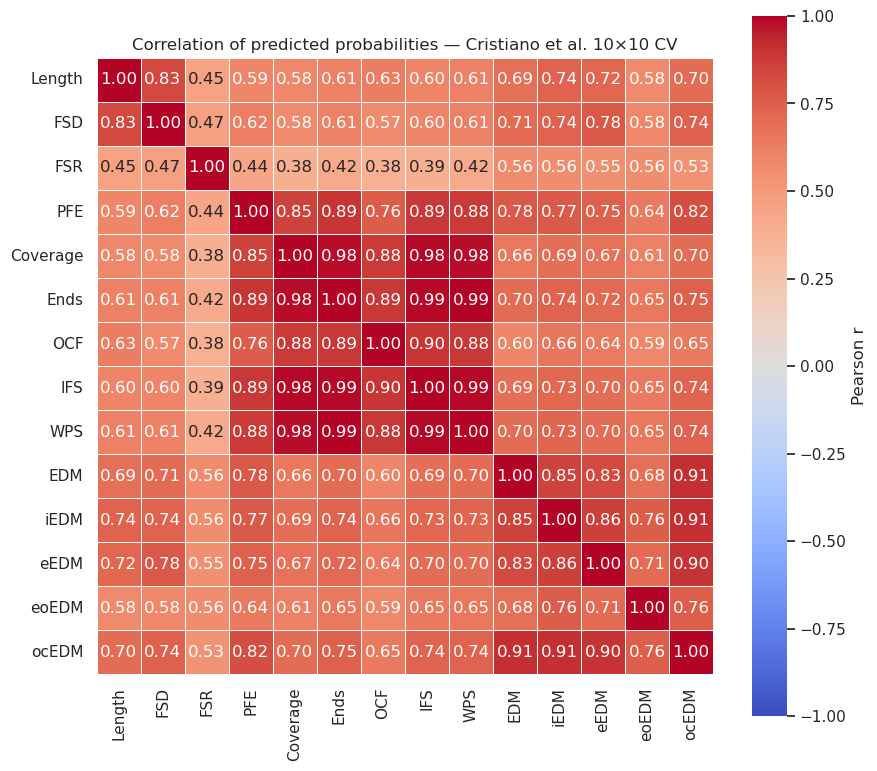

In [12]:
# B5 — Feature correlation heatmap
corr = probs_wide.drop(columns='sample_id').rename(columns=RENAME).corr()
plt.figure(figsize=(9, 8))
sns.set_theme(style="white")
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1,
            linewidths=0.5, square=True, cbar_kws={'label': 'Pearson r'})
plt.title('Correlation of predicted probabilities — Cristiano et al. 10×10 CV')
plt.tight_layout()
plt.savefig("scripts/analysis/figures/B5_feature_corr.png")
plt.show()


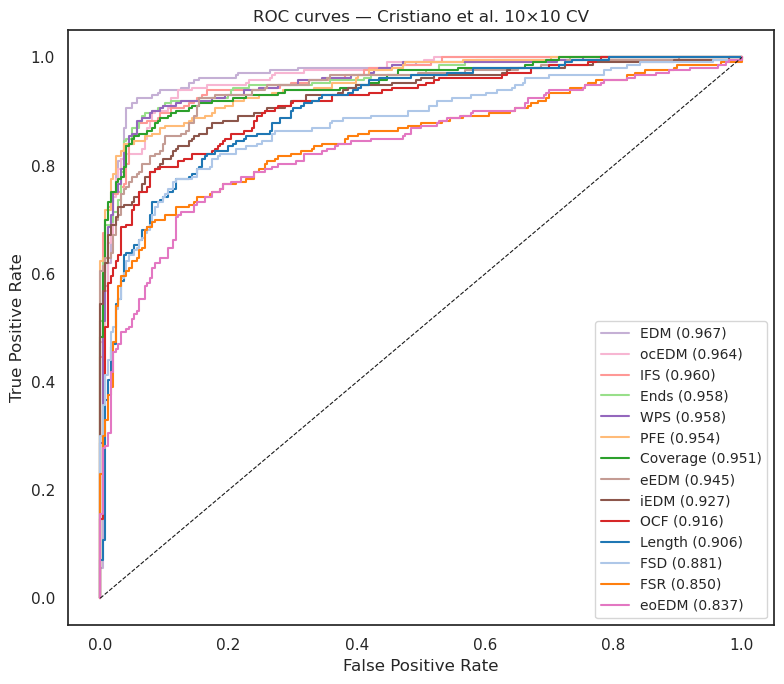

In [13]:
# B6 — ROC curves all features
fig, ax = plt.subplots(figsize=(8, 7))
sns.set_theme(style="whitegrid")
for d in cv_roc:
    ax.plot(d['fpr'], d['tpr'], color=feat_color(d['name']),
            label=f"{d['name']} ({d['auc']:.3f})", linewidth=1.5)
ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8)
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC curves — Cristiano et al. 10×10 CV')
ax.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.savefig("scripts/analysis/figures/B6_roc_cv.png", bbox_inches='tight')
plt.show()


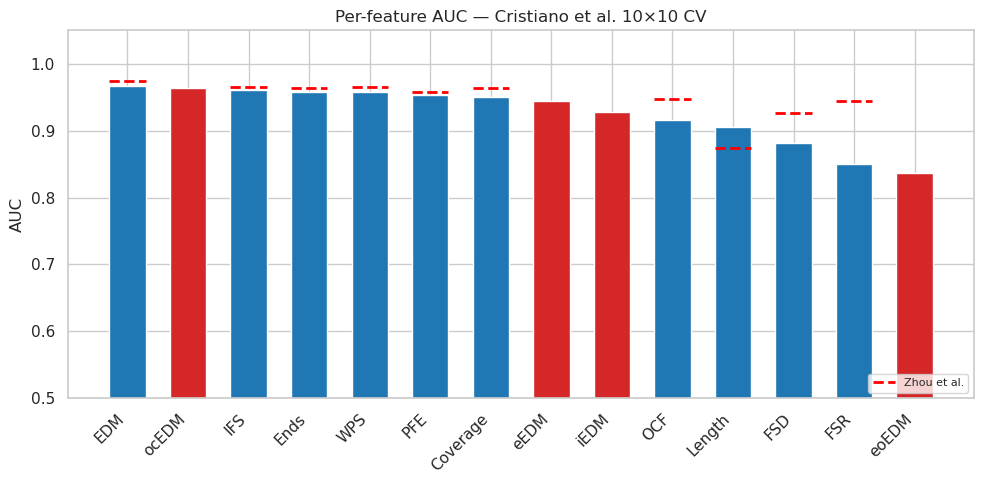

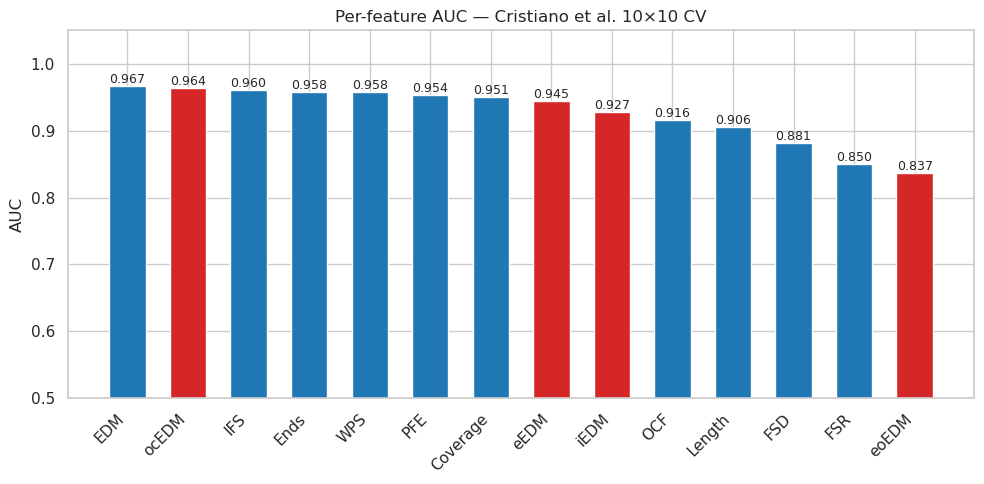

In [14]:
# B7 — AUC bars vs Zhou
fig, ax = plt.subplots(figsize=(10, 5))
sns.set_theme(style='whitegrid')
ax.bar(range(len(names)), aucs, color=[is_new_color(n) for n in names], width=0.6)
ax.set_xticks(range(len(names))); ax.set_xticklabels(names, rotation=45, ha='right')
ax.set_ylim(0.5, 1.05); ax.set_ylabel('AUC')
ax.set_title('Per-feature AUC — Cristiano et al. 10×10 CV')
for i, n in enumerate(names):
    z = ZHOU_SCORES.get(RENAME_INV.get(n, n))
    if z is not None:
        ax.hlines(z, i-0.3, i+0.3, colors='red', linewidth=2, linestyles='--',
                label='Zhou et al.' if i == 0 else '')
ax.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.savefig("scripts/analysis/figures/B7_auc_cv_zhou.png", bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(len(names)), aucs, color=[is_new_color(n) for n in names], width=0.6)
ax.set_xticks(range(len(names))); ax.set_xticklabels(names, rotation=45, ha='right')
ax.set_ylim(0.5, 1.05); ax.set_ylabel('AUC')
ax.set_title('Per-feature AUC — Cristiano et al. 10×10 CV')
for p in ax.patches:
    ax.annotate(f'{p.get_height():.3f}',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig("scripts/analysis/figures/B7_auc_cv.png", bbox_inches='tight')
plt.show()


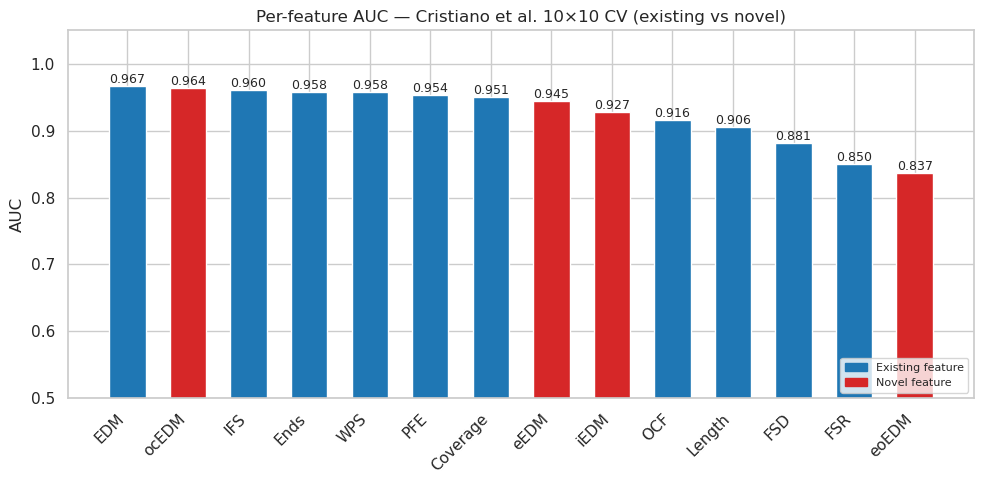

In [15]:
# B7b — AUC bars existing vs novel
fig, ax = plt.subplots(figsize=(10, 5))
sns.set_theme(style="whitegrid")
ax.bar(range(len(names)), aucs, color=[is_new_color(n) for n in names], width=0.6)
ax.set_xticks(range(len(names))); ax.set_xticklabels(names, rotation=45, ha='right')
ax.set_ylim(0.5, 1.05); ax.set_ylabel('AUC')
ax.set_title('Per-feature AUC — Cristiano et al. 10×10 CV (existing vs novel)')
ax.legend(handles=[Patch(color='#1f77b4', label='Existing feature'),
                   Patch(color='#d62728', label='Novel feature')],
          loc='lower right', fontsize=8)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.3f}',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig("scripts/analysis/figures/B7b_auc_oldnew_cv.png", bbox_inches='tight')
plt.show()


/tmp/ipykernel_1528215/1459615871.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_1528215/1459615871.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


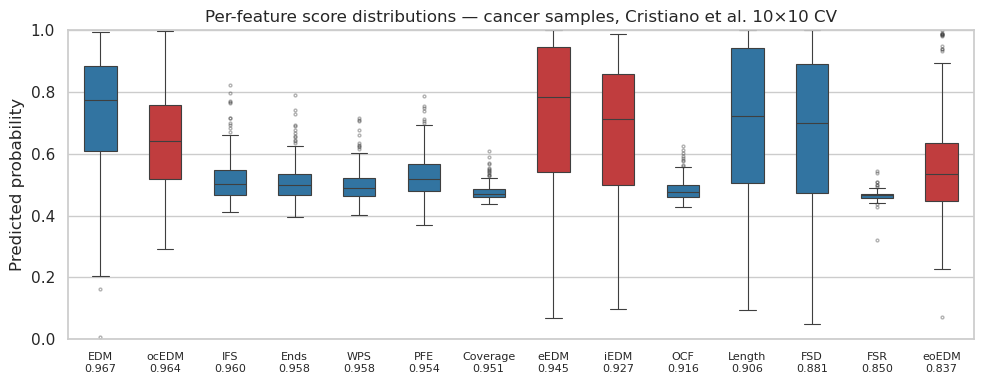

In [16]:
# B8 — Score distributions (cancer samples only, per feature)
label_df = pd.read_csv(cv_dir + 'length_cv_probs.csv')[['sample_id', 'label']]
feat_cols = [f for f in FEATURE_NAMES if f in probs_wide.columns]
long_df = (
    probs_wide[['sample_id'] + feat_cols]
    .melt(id_vars='sample_id', var_name='feature', value_name='probability')
    .merge(label_df, on='sample_id')
)
long_df['feature'] = long_df['feature'].map(lambda f: RENAME.get(f, f))
cancer_long = long_df[long_df['label'] == 1]

feat_order = [d['name'] for d in cv_roc]  # AUC desc
auc_lookup = {d['name']: d['auc'] for d in cv_roc}

fig, ax = plt.subplots(figsize=(10, 4))
sns.set_theme(style='whitegrid')
sns.boxplot(
    data=cancer_long, x='feature', y='probability',
    order=feat_order,
    palette=[is_new_color(f) for f in feat_order], width=0.5, linewidth=0.8,
    flierprops=dict(marker='o', markersize=2, alpha=0.4), ax=ax
)
ax.set_xticklabels(
    [f"{f}\n{auc_lookup.get(f, 0):.3f}" for f in feat_order], fontsize=8
)
ax.set_ylim(0, 1)
ax.set_xlabel('')
ax.set_ylabel('Predicted probability')
ax.set_title('Per-feature score distributions — cancer samples, Cristiano et al. 10×10 CV')
plt.tight_layout()
plt.savefig('scripts/analysis/figures/B8_score_dist_cancer.png', bbox_inches='tight')
plt.show()

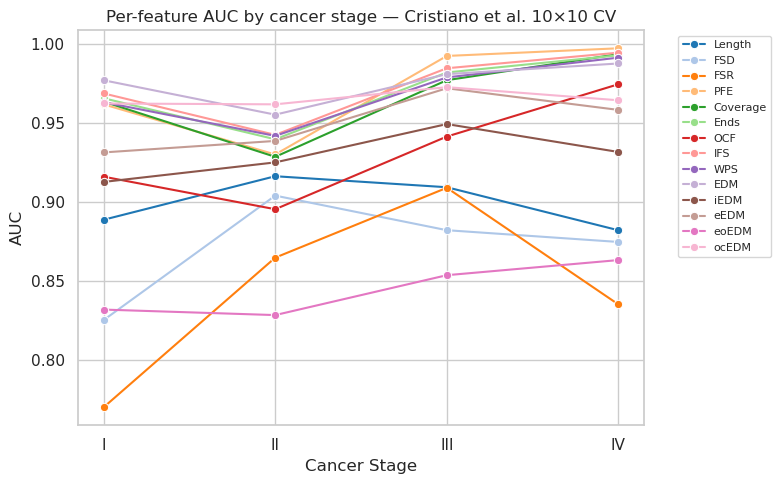

In [17]:
# B9 — Stage-stratified AUC
palette = {RENAME.get(f, f): feat_color(RENAME.get(f, f)) for f in FEATURE_NAMES}
plt.figure(figsize=(8, 5))
sns.set_theme(style="whitegrid")
sns.lineplot(data=stage_auc, x='stage', y='auc', hue='feature', marker='o', palette=palette)
plt.xlabel('Cancer Stage'); plt.ylabel('AUC')
plt.title('Per-feature AUC by cancer stage — Cristiano et al. 10×10 CV')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig("scripts/analysis/figures/B9_stage_auc_cv.png", bbox_inches='tight')
plt.show()


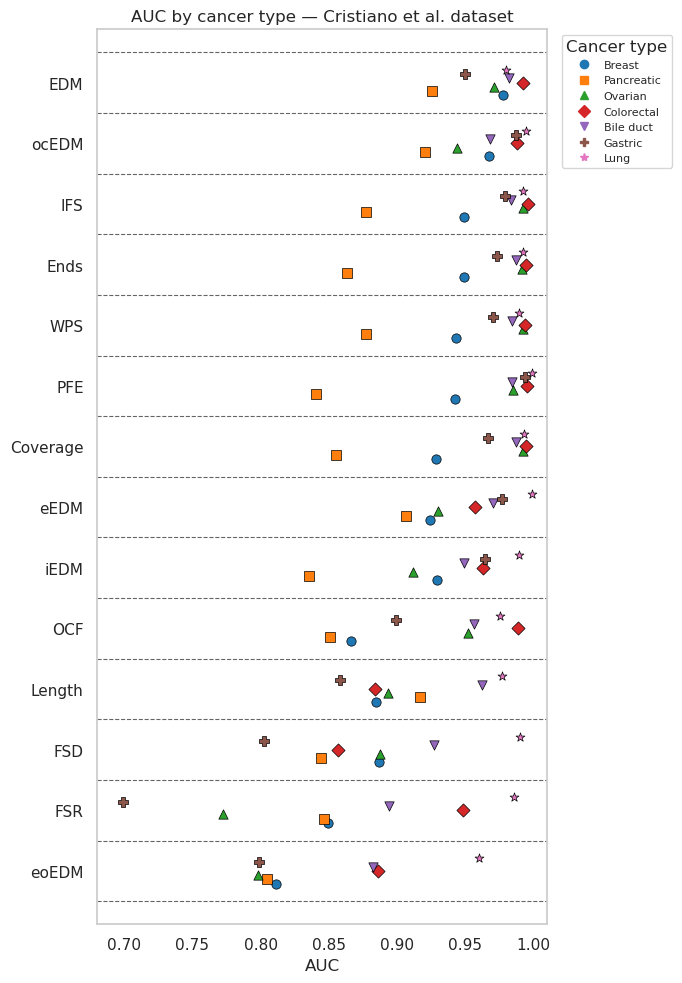

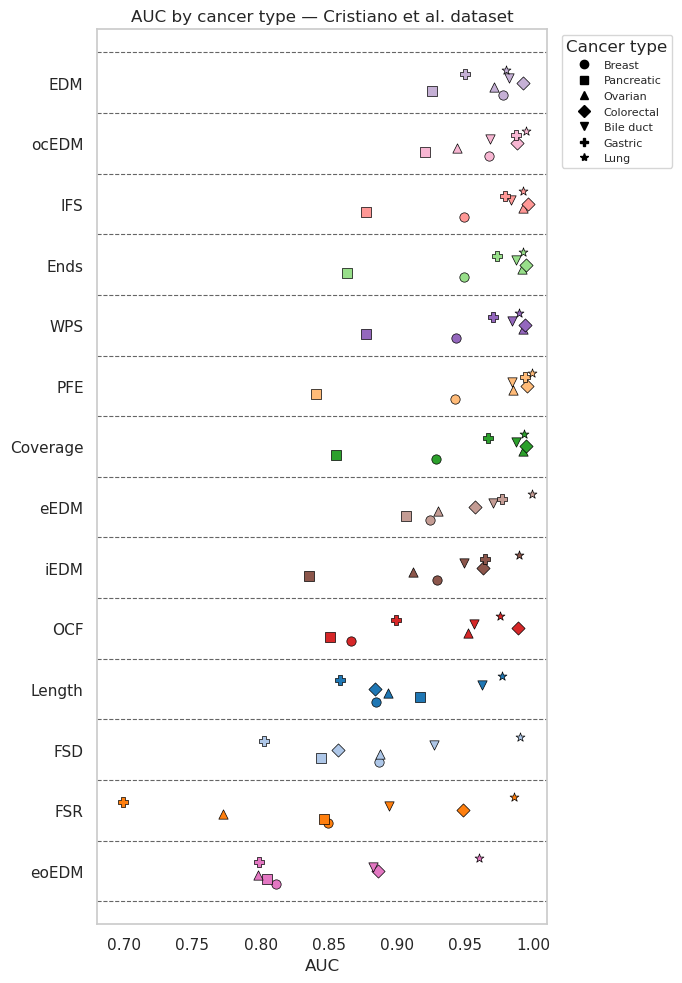

In [18]:
# B — Forest plot: per-feature AUC by cancer type (Cristiano 10×10 CV)
from matplotlib.lines import Line2D

feat_order_f = [d['name'] for d in cv_roc]  # AUC desc

cancer_types_f = (cancer_type_auc_df.groupby('cancer_type')['n']
                  .first().sort_values(ascending=False).index.tolist())
short_ct = {ct: CANCER_RENAME.get(ct, ct) for ct in cancer_types_f}

marker_pool = ['o', 's', '^', 'D', 'v', 'P', '*', 'X', 'h', 'p']
type_markers = {ct: marker_pool[i % len(marker_pool)] for i, ct in enumerate(cancer_types_f)}
type_pal = sns.color_palette('tab10', len(cancer_types_f))
type_colors = {ct: type_pal[i] for i, ct in enumerate(cancer_types_f)}

n_feats = len(feat_order_f)
n_types = len(cancer_types_f)
y_spread = 0.07

fig, ax = plt.subplots(figsize=(7, 10))
for i, feat in enumerate(feat_order_f):
    y = n_feats - 1 - i
    feat_data = cancer_type_auc_df[cancer_type_auc_df['feature'] == feat]
    for j, ct in enumerate(cancer_types_f):
        row = feat_data[feat_data['cancer_type'] == ct]
        if row.empty:
            continue
        jitter = (j - (n_types - 1) / 2) * y_spread
        ax.scatter(row['auc'].values[0], y + jitter,
                   color=type_colors[ct], marker=type_markers[ct],
                   s=45, zorder=3, edgecolor='black', linewidth=0.5)
ax.set_yticks(range(n_feats))
ax.set_yticklabels(feat_order_f[::-1])
ax.set_xlim(0.68, 1.01)
ax.set_xlabel('AUC')
ax.set_title('AUC by cancer type — Cristiano et al. dataset')
ct_handles = [Line2D([0], [0], marker=type_markers[ct], color=type_colors[ct],
                     linestyle='None', markersize=6, label=short_ct[ct])
              for ct in cancer_types_f]
ax.legend(handles=ct_handles, title='Cancer type',
          bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
ax.xaxis.grid(False)
ax.yaxis.grid(False)
for sep in [k + 0.5 for k in range(-1, n_feats)]:
    ax.axhline(sep, color='#656565', linewidth=0.8, zorder=0, linestyle='--')
plt.tight_layout()
plt.savefig('scripts/analysis/figures/B_forest_cancer_type_cv.png', bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(7, 10))
for i, feat in enumerate(feat_order_f):
    y = n_feats - 1 - i
    feat_data = cancer_type_auc_df[cancer_type_auc_df['feature'] == feat]
    for j, ct in enumerate(cancer_types_f):
        row = feat_data[feat_data['cancer_type'] == ct]
        if row.empty:
            continue
        jitter = (j - (n_types - 1) / 2) * y_spread
        ax.scatter(row['auc'].values[0], y + jitter,
                   color=feat_color(feat), marker=type_markers[ct],
                   s=45, zorder=3, edgecolor='black', linewidth=0.5)
ax.set_yticks(range(n_feats))
ax.set_yticklabels(feat_order_f[::-1])
ax.set_xlim(0.68, 1.01)
ax.set_xlabel('AUC')
ax.set_title('AUC by cancer type — Cristiano et al. dataset')
ct_handles = [Line2D([0], [0], marker=type_markers[ct], color='black',
                     linestyle='None', markersize=6, label=short_ct[ct])
              for ct in cancer_types_f]
ax.legend(handles=ct_handles, title='Cancer type',
          bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
ax.xaxis.grid(False)
ax.yaxis.grid(False)
for sep in [k + 0.5 for k in range(-1, n_feats)]:
    ax.axhline(sep, color='#656565', linewidth=0.8, zorder=0, linestyle='--')
plt.tight_layout()
plt.savefig('scripts/analysis/figures/B_forest_cancer_type_cv_v2.png', bbox_inches='tight')
plt.show()

## C — Cristiano ensemble

In [19]:
ens_dir = "data/matrix/svm_by_feature/svm_linear_pca150.0_gc_mapq30/ensemble_nostd/cv/"
ens_df  = pd.read_csv(ens_dir + "cv_probs.csv").rename(columns={'Unnamed: 0': 'sample_id'})

ens_fpr, ens_tpr, _ = roc_curve(ens_df['label'], ens_df['probability'])
ens_auc  = roc_auc_score(ens_df['label'], ens_df['probability'])
ens_merge = ens_df[['sample_id', 'probability', 'label']].merge(manifest, on='sample_id', how='left')

cancer_types = (ens_merge[ens_merge['label'] == 1]['disease']
                .value_counts().loc[lambda s: s >= 5].index.tolist())
healthy  = ens_merge[ens_merge['disease'] == 'Healthy']
panels   = ['All cancers'] + cancer_types
type_aucs = {ct: roc_auc_score(
                pd.concat([ens_merge[ens_merge['disease'] == ct], healthy])['label'],
                pd.concat([ens_merge[ens_merge['disease'] == ct], healthy])['probability'])
             for ct in cancer_types}
type_ns = {ct: len(ens_merge[ens_merge['disease'] == ct]) for ct in cancer_types}
print(f"Ensemble AUC: {ens_auc:.4f}  (n={len(ens_df)})")


Ensemble AUC: 0.9918  (n=459)


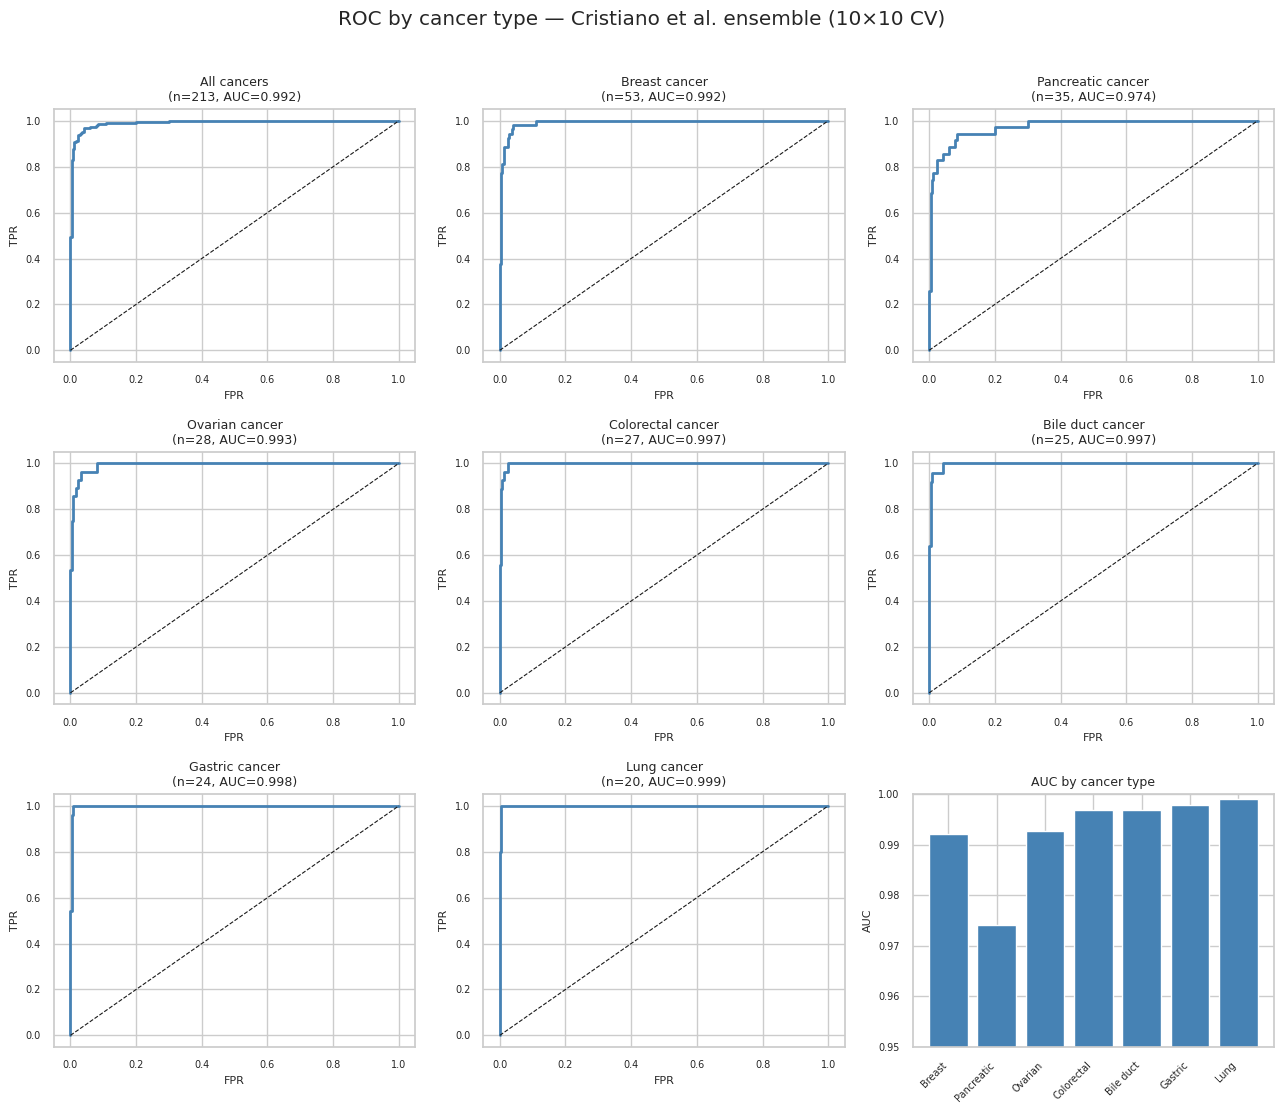

In [20]:
# C12 — ROC by cancer type, 3×3 grid
fig, axes = plt.subplots(3, 3, figsize=(13, 11))
sns.set_theme(style="whitegrid")
for i, ax in enumerate(axes.flatten()):
    if i < len(panels):
        cancer = ens_merge[ens_merge['label'] == 1] if panels[i] == 'All cancers' else ens_merge[ens_merge['disease'] == panels[i]]
        subset = pd.concat([cancer, healthy])
        fpr_t, tpr_t, thresholds = roc_curve(subset['label'], subset['probability'])
        auc_t = roc_auc_score(subset['label'], subset['probability'])
        ax.plot(fpr_t, tpr_t, color='steelblue', lw=2)
        ax.plot([0, 1], [0, 1], 'k--', lw=0.8)
        ax.set_title(f"{panels[i]}\n(n={len(cancer)}, AUC={auc_t:.3f})", fontsize=9)
        ax.set_xlabel('FPR', fontsize=8); ax.set_ylabel('TPR', fontsize=8)
        ax.tick_params(labelsize=7)
    else:
        short = [CANCER_RENAME.get(ct, ct) for ct in cancer_types]
        auc_vals = [type_aucs[ct] for ct in cancer_types]
        ax.bar(range(len(cancer_types)), auc_vals, color='steelblue')
        ax.set_xticks(range(len(cancer_types)))
        ax.set_xticklabels(short, rotation=45, ha='right', fontsize=9)
        ax.set_ylim(0.95, 1.0); ax.set_ylabel('AUC', fontsize=8)
        ax.set_title('AUC by cancer type', fontsize=9)
        ax.tick_params(labelsize=7)
plt.suptitle('ROC by cancer type — Cristiano et al. ensemble (10×10 CV)', y=1.01)
plt.tight_layout()
plt.savefig("scripts/analysis/figures/C12_roc_cancer_type_grid.png", bbox_inches='tight')
plt.show()


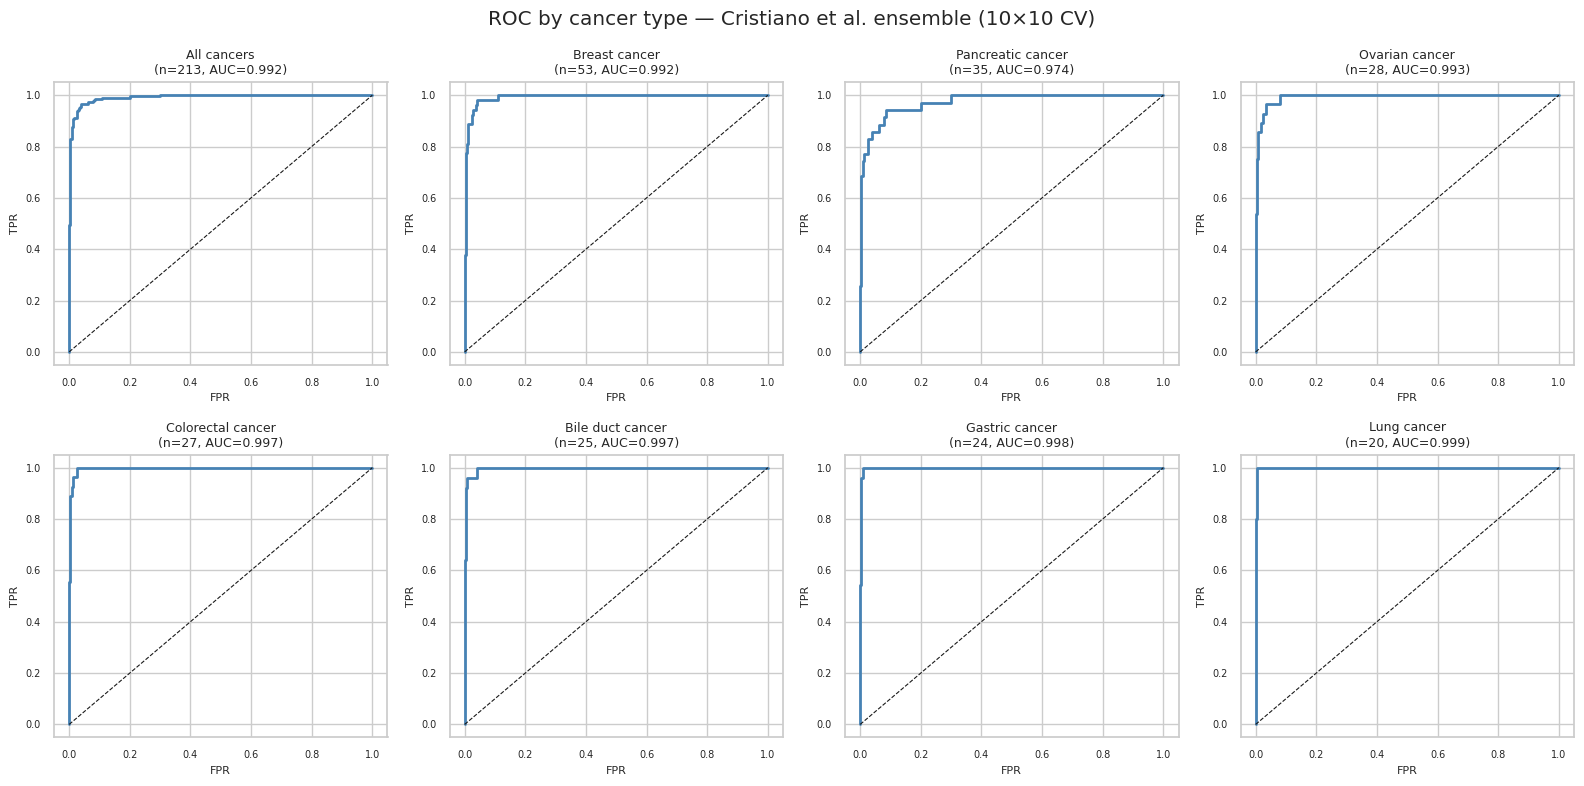

In [21]:
# 2×4 
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
sns.set_theme(style="whitegrid")
for ax, panel in zip(axes.flatten(), panels):
    if panel == 'All cancers':
        cancer = ens_merge[ens_merge['label'] == 1]
    else:
        cancer = ens_merge[ens_merge['disease'] == panel]
    subset = pd.concat([cancer, healthy])
    fpr_t, tpr_t, thresholds = roc_curve(subset['label'], subset['probability'])
    auc_t = roc_auc_score(subset['label'], subset['probability'])
    ax.plot(fpr_t, tpr_t, color='steelblue', lw=2)
    ax.plot([0, 1], [0, 1], 'k--', lw=0.8)
    ax.set_title(f"{panel}\n(n={len(cancer)}, AUC={auc_t:.3f})", fontsize=9)
    ax.set_xlabel('FPR', fontsize=8); ax.set_ylabel('TPR', fontsize=8)
    ax.tick_params(labelsize=7)
plt.suptitle('ROC by cancer type — Cristiano et al. ensemble (10×10 CV)')
plt.tight_layout()
plt.savefig("scripts/analysis/figures/C12b_roc_cancer_type_2x4.png", bbox_inches='tight')
plt.show()

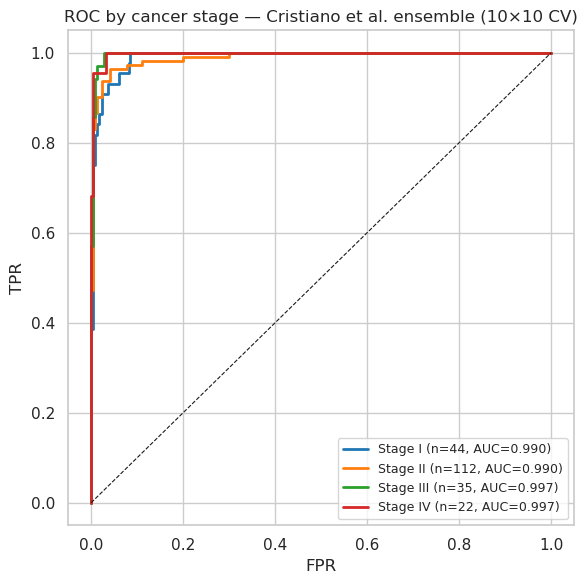

In [22]:
stage_colors = {'I': '#1f77b4', 'II': '#ff7f0e', 'III': '#2ca02c', 'IV': '#d62728'}
healthy_ens  = ens_merge[ens_merge['disease'] == 'Healthy']

fig, ax = plt.subplots(figsize=(6, 6))
sns.set_theme(style="whitegrid")
for stage in ['I', 'II', 'III', 'IV']:
    cancer = ens_merge[(ens_merge['label'] == 1) & (ens_merge['stage'] == stage)]
    if len(cancer) == 0:
        continue
    subset = pd.concat([cancer, healthy_ens])
    fpr_s, tpr_s, thresholds = roc_curve(subset['label'], subset['probability'])
    auc_s = roc_auc_score(subset['label'], subset['probability'])
    ax.plot(fpr_s, tpr_s, color=stage_colors[stage], lw=2,
            label=f"Stage {stage} (n={len(cancer)}, AUC={auc_s:.3f})")
ax.plot([0, 1], [0, 1], 'k--', lw=0.8)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('ROC by cancer stage — Cristiano et al. ensemble (10×10 CV)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("scripts/analysis/figures/C13_roc_stage_ensemble.png", bbox_inches='tight')
plt.show()

/tmp/ipykernel_1528215/1405078096.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_1528215/1405078096.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


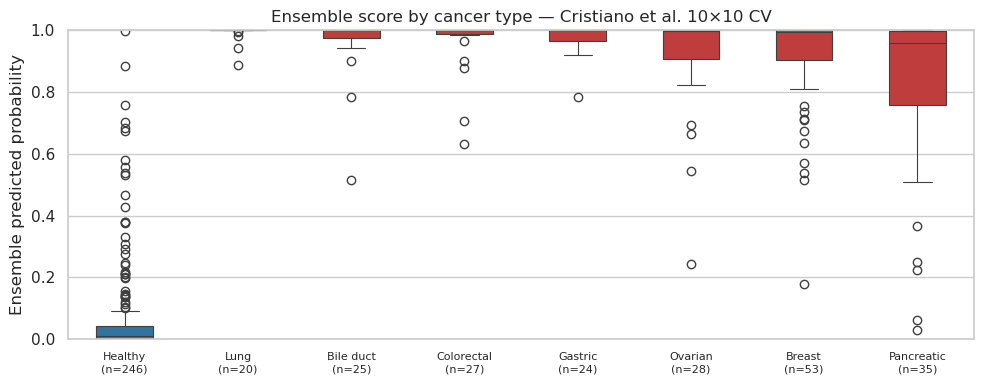

In [23]:
# C — Ensemble score by cancer type
exclude = {'Duodenal cancer'}  # n=1
ct_df = ens_merge[~ens_merge['disease'].isin(exclude)]

cancer_medians = (
    ct_df[ct_df['label'] == 1]
    .groupby('disease')['probability'].median()
    .sort_values(ascending=False)
)
order =  ['Healthy'] + cancer_medians.index.tolist()
palette = {t: '#d62728' for t in cancer_medians.index}
palette['Healthy'] = '#1f77b4'
ns = ct_df.groupby('disease')['sample_id'].count()

fig, ax = plt.subplots(figsize=(10, 4))
sns.set_theme(style='whitegrid')
sns.boxplot(
    data=ct_df, x='disease', y='probability',
    order=order, palette=palette,
    width=0.5, linewidth=0.8,
)
ax.set_xticklabels(
    [f"{CANCER_RENAME.get(t, t)}\n(n={ns.get(t, 0)})" for t in order],
    fontsize=8
)
ax.set_ylim(0, 1)
ax.set_xlabel('')
ax.set_ylabel('Ensemble predicted probability')
ax.set_title('Ensemble score by cancer type — Cristiano et al. 10×10 CV')
plt.tight_layout()
plt.savefig('scripts/analysis/figures/C_score_by_cancer_type.png', bbox_inches='tight')
plt.show()

## C (nofsr ensemble) — Cristiano nofsr ensemble (13-feature, no fsr)

In [24]:
nofsr_ens_base = "data/matrix/svm_by_feature/svm_linear_pca150.0_gc_mapq30/ensemble_nostd_nofsr/"

nofsr_cv_df = pd.read_csv(nofsr_ens_base + "cv/cv_probs.csv").rename(columns={'Unnamed: 0': 'sample_id'})
nofsr_cv_fpr, nofsr_cv_tpr, _ = roc_curve(nofsr_cv_df['label'], nofsr_cv_df['probability'])
nofsr_cv_auc = roc_auc_score(nofsr_cv_df['label'], nofsr_cv_df['probability'])
nofsr_cv_merge = nofsr_cv_df.merge(manifest, on='sample_id', how='left')

nofsr_cv_roc_feats = [d for d in cv_roc if d['name'] != 'fsr']
names_nofsr_cv = [d['name'] for d in nofsr_cv_roc_feats]
aucs_nofsr_cv  = [d['auc']  for d in nofsr_cv_roc_feats]

nofsr_healthy      = nofsr_cv_merge[nofsr_cv_merge['disease'] == 'Healthy']
nofsr_cancer_types = (nofsr_cv_merge[nofsr_cv_merge['label'] == 1]['disease']
                      .value_counts().loc[lambda s: s >= 5].index.tolist())
nofsr_panels = ['All cancers'] + nofsr_cancer_types
print(f"nofsr ensemble CV AUC: {nofsr_cv_auc:.4f}  (n={len(nofsr_cv_df)})")


nofsr ensemble CV AUC: 0.9918  (n=459)


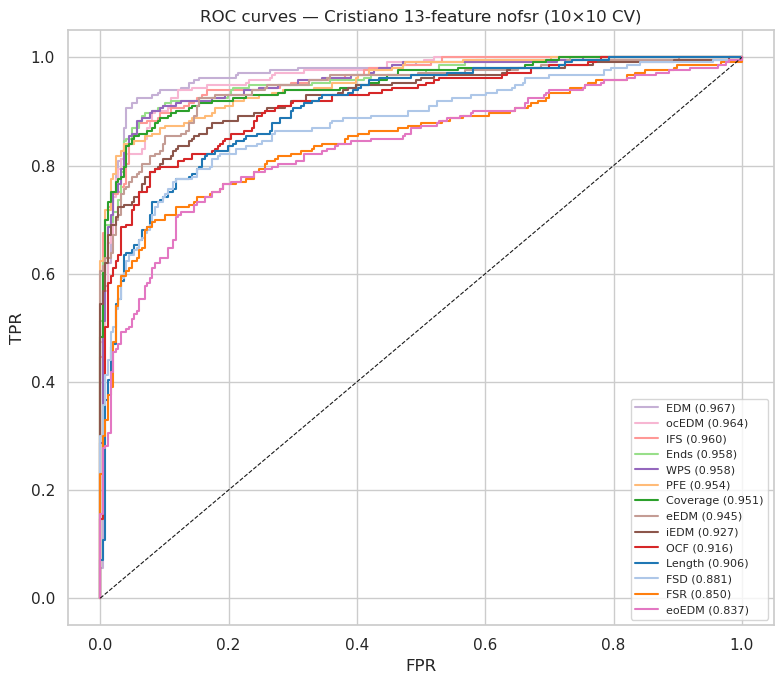

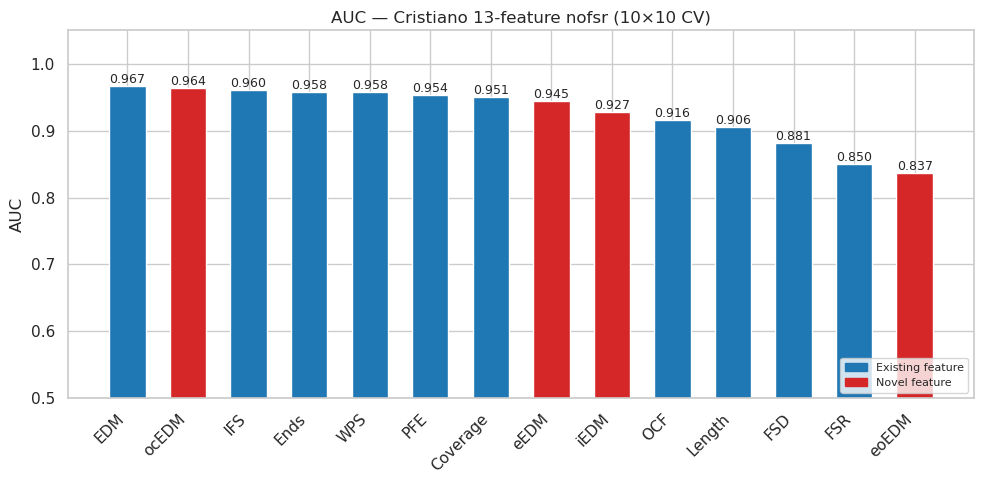

In [25]:
# C nofsr — per-feature ROC + AUC bars
fig, ax = plt.subplots(figsize=(8, 7))
sns.set_theme(style="whitegrid")
for d in nofsr_cv_roc_feats:
    ax.plot(d['fpr'], d['tpr'], color=feat_color(d['name']),
            label=f"{d['name']} ({d['auc']:.3f})", linewidth=1.5)
ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('ROC curves — Cristiano 13-feature nofsr (10×10 CV)')
ax.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.savefig("scripts/analysis/figures/C_nofsr_roc_cv.png", bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
sns.set_theme(style="whitegrid")
ax.bar(range(len(names_nofsr_cv)), aucs_nofsr_cv,
        color=[is_new_color(n) for n in names_nofsr_cv], width=0.6)
ax.set_xticks(range(len(names_nofsr_cv))); ax.set_xticklabels(names_nofsr_cv, rotation=45, ha='right')
ax.set_ylim(0.5, 1.05); ax.set_ylabel('AUC')
ax.set_title('AUC — Cristiano 13-feature nofsr (10×10 CV)')
ax.legend(handles=[Patch(color='#1f77b4', label='Existing feature'),
                   Patch(color='#d62728', label='Novel feature')],
          loc='lower right', fontsize=8)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.3f}',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig("scripts/analysis/figures/C_nofsr_auc_cv.png", bbox_inches='tight')
plt.show()


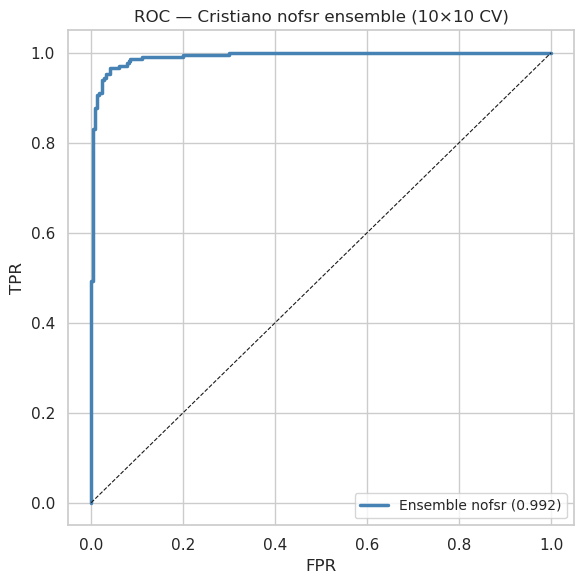

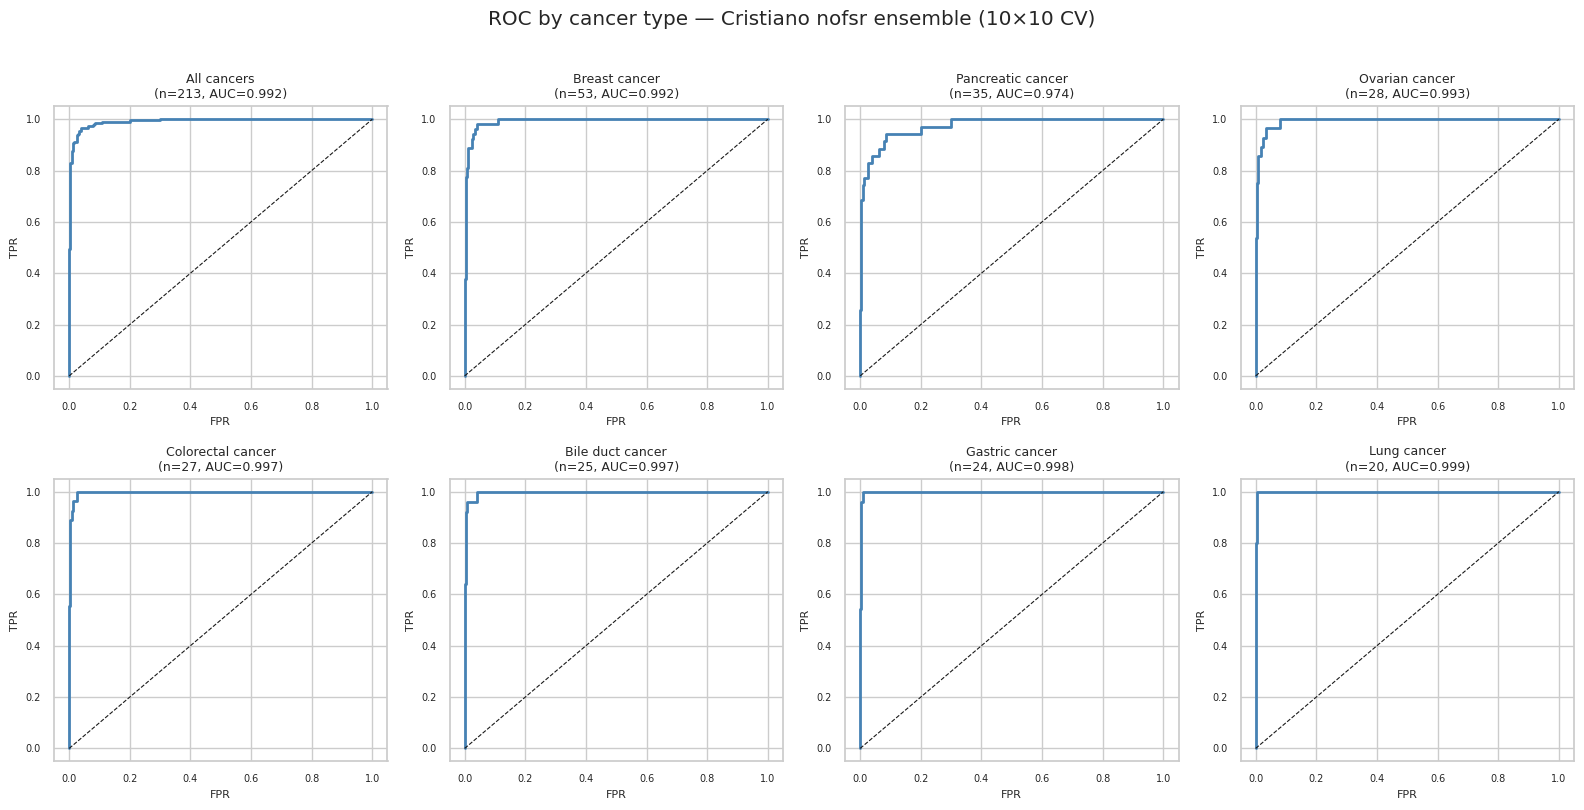

In [26]:
# Ensemble single ROC
fig, ax = plt.subplots(figsize=(6, 6))
sns.set_theme(style="whitegrid")
ax.plot(nofsr_cv_fpr, nofsr_cv_tpr, color='steelblue', linewidth=2.5,
        label=f"Ensemble nofsr ({nofsr_cv_auc:.3f})")
ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('ROC — Cristiano nofsr ensemble (10×10 CV)')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig("scripts/analysis/figures/C_nofsr_ens_roc_cv.png", bbox_inches='tight')
plt.show()

nofsr_healthy = nofsr_cv_merge[nofsr_cv_merge['disease'] == 'Healthy']
nofsr_cancer_types = (nofsr_cv_merge[nofsr_cv_merge['label'] == 1]['disease']
                      .value_counts()
                      .loc[lambda s: s >= 5].index.tolist())
nofsr_panels = ['All cancers'] + nofsr_cancer_types

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
sns.set_theme(style="whitegrid")
for ax, panel in zip(axes.flatten(), nofsr_panels):
    cancer = (nofsr_cv_merge[nofsr_cv_merge['label'] == 1] if panel == 'All cancers'
              else nofsr_cv_merge[nofsr_cv_merge['disease'] == panel])
    subset = pd.concat([cancer, nofsr_healthy])
    fpr_t, tpr_t, thresholds = roc_curve(subset['label'], subset['probability'])
    auc_t = roc_auc_score(subset['label'], subset['probability'])
    ax.plot(fpr_t, tpr_t, color='steelblue', lw=2)
    ax.plot([0, 1], [0, 1], 'k--', lw=0.8)
    ax.set_title(f"{panel}\n(n={len(cancer)}, AUC={auc_t:.3f})", fontsize=9)
    ax.set_xlabel('FPR', fontsize=8); ax.set_ylabel('TPR', fontsize=8)
    ax.tick_params(labelsize=7)
for ax in axes.flatten()[len(nofsr_panels):]:
    ax.set_visible(False)
plt.suptitle('ROC by cancer type — Cristiano nofsr ensemble (10×10 CV)', y=1.01)
plt.tight_layout()
plt.savefig("scripts/analysis/figures/C_nofsr_ens_cancer_type_cv.png", bbox_inches='tight')
plt.show()


## D — External validation (Cristiano-trained)

In [27]:
ly_test_dir = "data/matrix/svm_by_feature/svm_linear_pca150.0_gc_mapq30/test/prevelynch_test/"
gs_test_dir = "data/matrix/svm_by_feature/svm_linear_pca150.0_gc_mapq30/test/genoscan/"

cr_ly_roc = load_roc_data(ly_test_dir)
cr_gs_roc = load_roc_data(gs_test_dir)

names_ly = [d['name'] for d in cr_ly_roc]; aucs_ly = [d['auc'] for d in cr_ly_roc]
names_gs = [d['name'] for d in cr_gs_roc]; aucs_gs = [d['auc'] for d in cr_gs_roc]


Missing: ['fsr']
Missing: ['fsr']


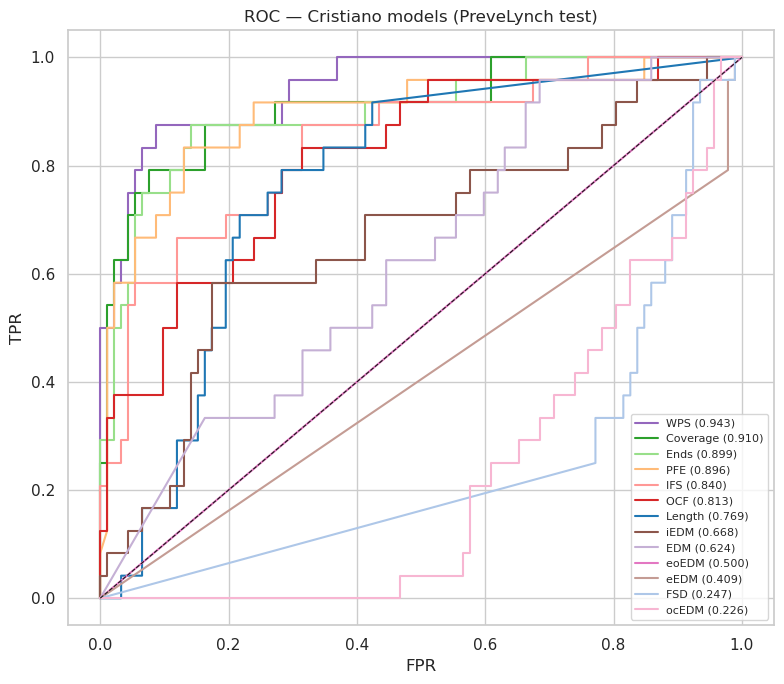

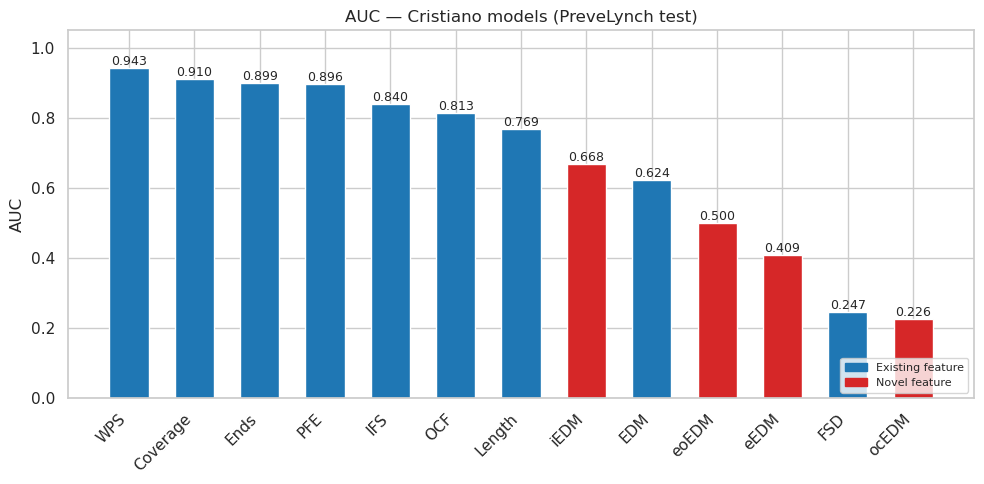

In [28]:
# D14 — Cristiano → PreveLynch ROC + AUC bars
fig, ax = plt.subplots(figsize=(8, 7))
sns.set_theme(style="whitegrid")
for d in cr_ly_roc:
    ax.plot(d['fpr'], d['tpr'], color=feat_color(d['name']),
            label=f"{d['name']} ({d['auc']:.3f})", linewidth=1.5)
ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('ROC — Cristiano models (PreveLynch test)')
ax.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.savefig("scripts/analysis/figures/D14_roc_crist_ly.png", bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
sns.set_theme(style="whitegrid")
ax.bar(range(len(names_ly)), aucs_ly, color=[is_new_color(n) for n in names_ly], width=0.6)
ax.set_xticks(range(len(names_ly))); ax.set_xticklabels(names_ly, rotation=45, ha='right')
ax.set_ylim(0, 1.05); ax.set_ylabel('AUC')
ax.set_title('AUC — Cristiano models (PreveLynch test)')
ax.legend(handles=[Patch(color='#1f77b4', label='Existing feature'),
                   Patch(color='#d62728', label='Novel feature')],
          loc='lower right', fontsize=8)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.3f}',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig("scripts/analysis/figures/D14b_auc_crist_ly.png", bbox_inches='tight')
plt.show()


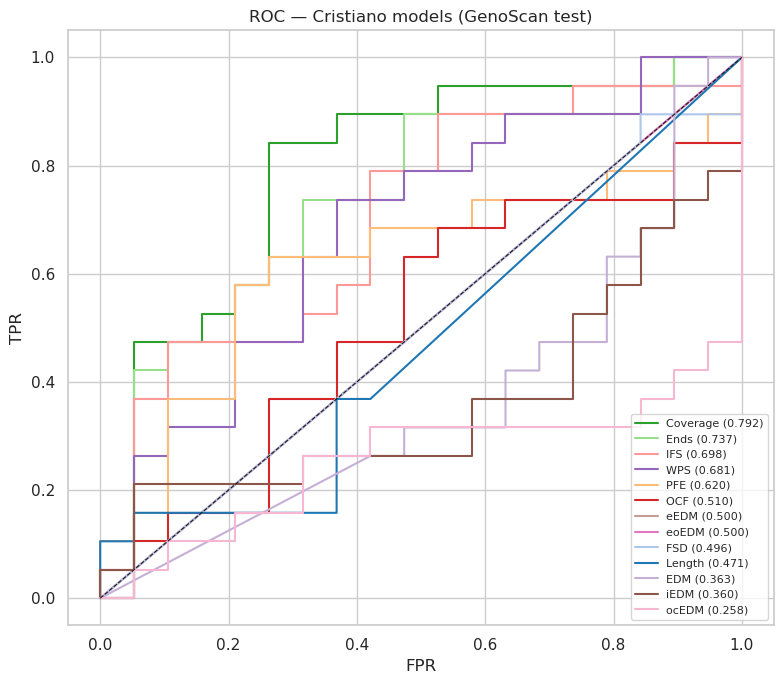

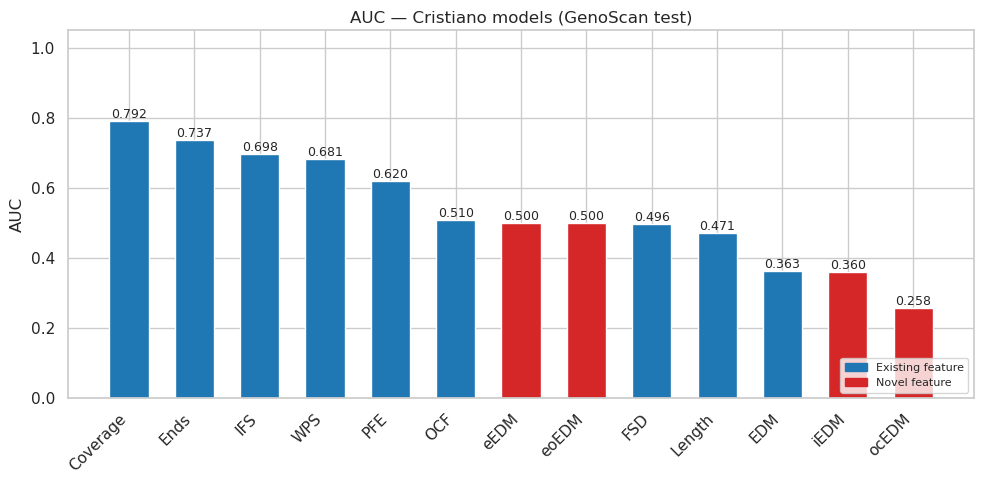

In [29]:
# D15 — Cristiano train, GenoScan test ROC + AUC bars
fig, ax = plt.subplots(figsize=(8, 7))
sns.set_theme(style="whitegrid")
for d in cr_gs_roc:
    ax.plot(d['fpr'], d['tpr'], color=feat_color(d['name']),
            label=f"{d['name']} ({d['auc']:.3f})", linewidth=1.5)
ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('ROC — Cristiano models (GenoScan test)')
ax.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.savefig("scripts/analysis/figures/D15_roc_crist_gs.png", bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
sns.set_theme(style="whitegrid")
ax.bar(range(len(names_gs)), aucs_gs, color=[is_new_color(n) for n in names_gs], width=0.6)
ax.set_xticks(range(len(names_gs))); ax.set_xticklabels(names_gs, rotation=45, ha='right')
ax.set_ylim(0, 1.05); ax.set_ylabel('AUC')
ax.set_title('AUC — Cristiano models (GenoScan test)')
ax.legend(handles=[Patch(color='#1f77b4', label='Existing feature'),
                   Patch(color='#d62728', label='Novel feature')],
          loc='lower right', fontsize=8)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.3f}',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig("scripts/analysis/figures/D15b_auc_crist_gs.png", bbox_inches='tight')
plt.show()


## D (nofsr ensemble) — Cristiano nofsr ensemble external test

In [30]:
nofsr_test_base = nofsr_ens_base + "test/ensemble_nostd_nofsr/test/"

nofsr_ly_df = pd.read_csv(nofsr_test_base + "prevelynch_test_preds.csv")
nofsr_ly_fpr, nofsr_ly_tpr, _ = roc_curve(nofsr_ly_df['label'], nofsr_ly_df['probability'])
nofsr_ly_auc = roc_auc_score(nofsr_ly_df['label'], nofsr_ly_df['probability'])

nofsr_gs_df = pd.read_csv(nofsr_test_base + "genoscan_preds.csv")
nofsr_gs_fpr, nofsr_gs_tpr, _ = roc_curve(nofsr_gs_df['label'], nofsr_gs_df['probability'])
nofsr_gs_auc = roc_auc_score(nofsr_gs_df['label'], nofsr_gs_df['probability'])

print(f"nofsr ensemble → LY AUC: {nofsr_ly_auc:.4f}  (n={len(nofsr_ly_df)})")
print(f"nofsr ensemble → GS AUC: {nofsr_gs_auc:.4f}  (n={len(nofsr_gs_df)})")


nofsr ensemble → LY AUC: 0.8886  (n=116)
nofsr ensemble → GS AUC: 0.5097  (n=38)


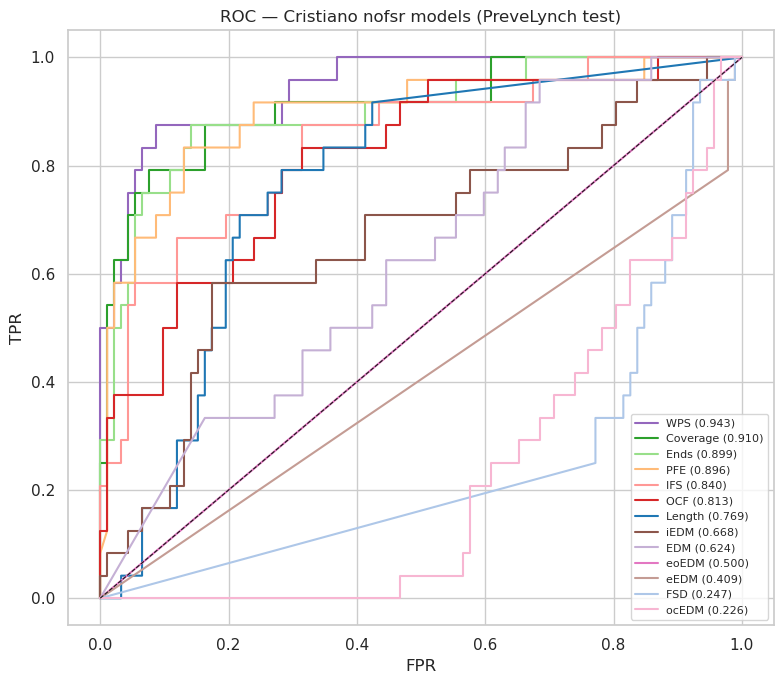

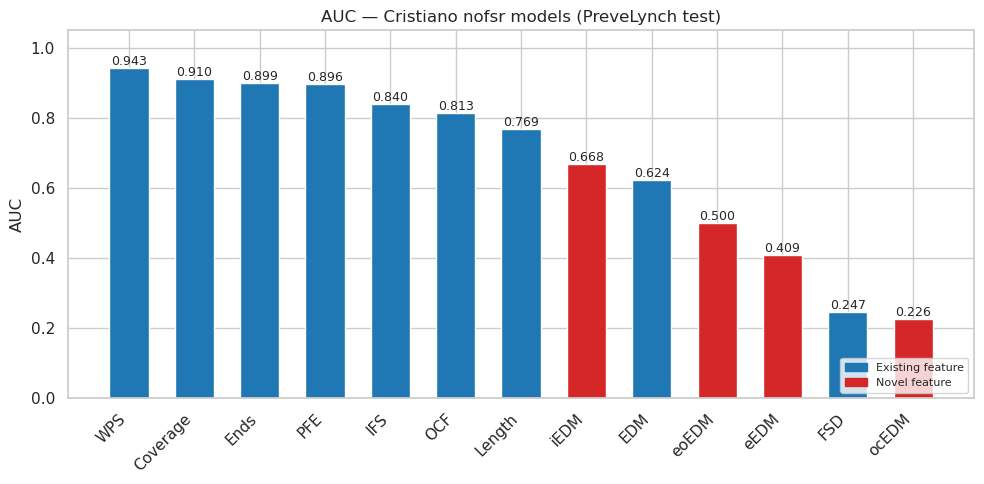

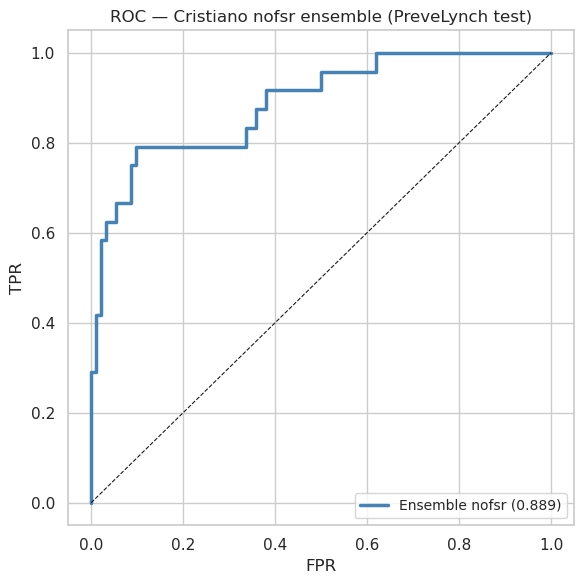

In [31]:
# D nofsr — PreveLynch: per-feature ROC + nofsr ensemble ROC
fig, ax = plt.subplots(figsize=(8, 7))
sns.set_theme(style="whitegrid")
for d in cr_ly_roc:
    ax.plot(d['fpr'], d['tpr'], color=feat_color(d['name']),
            label=f"{d['name']} ({d['auc']:.3f})", linewidth=1.5)
ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('ROC — Cristiano nofsr models (PreveLynch test)')
ax.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.savefig("scripts/analysis/figures/D_nofsr_roc_ly.png", bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
sns.set_theme(style="whitegrid")
ax.bar(range(len(names_ly)), aucs_ly, color=[is_new_color(n) for n in names_ly], width=0.6)
ax.set_xticks(range(len(names_ly))); ax.set_xticklabels(names_ly, rotation=45, ha='right')
ax.set_ylim(0, 1.05); ax.set_ylabel('AUC')
ax.set_title('AUC — Cristiano nofsr models (PreveLynch test)')
ax.legend(handles=[Patch(color='#1f77b4', label='Existing feature'),
                   Patch(color='#d62728', label='Novel feature')],
          loc='lower right', fontsize=8)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.3f}',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig("scripts/analysis/figures/D_nofsr_auc_ly.png", bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(6, 6))
sns.set_theme(style="whitegrid")
ax.plot(nofsr_ly_fpr, nofsr_ly_tpr, color='steelblue', linewidth=2.5,
        label=f"Ensemble nofsr ({nofsr_ly_auc:.3f})")
ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('ROC — Cristiano nofsr ensemble (PreveLynch test)')
ax.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.savefig("scripts/analysis/figures/D_nofsr_ens_roc_ly.png", bbox_inches='tight')
plt.show()


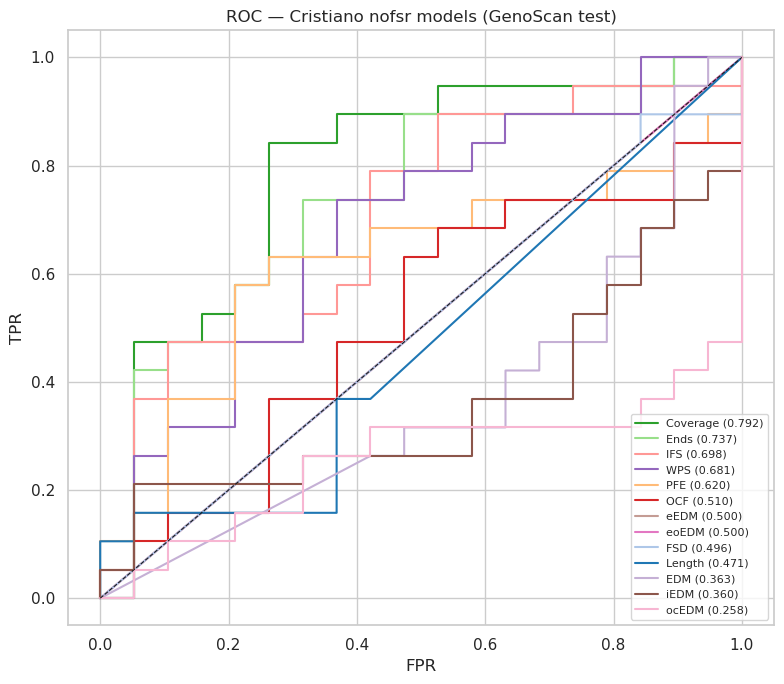

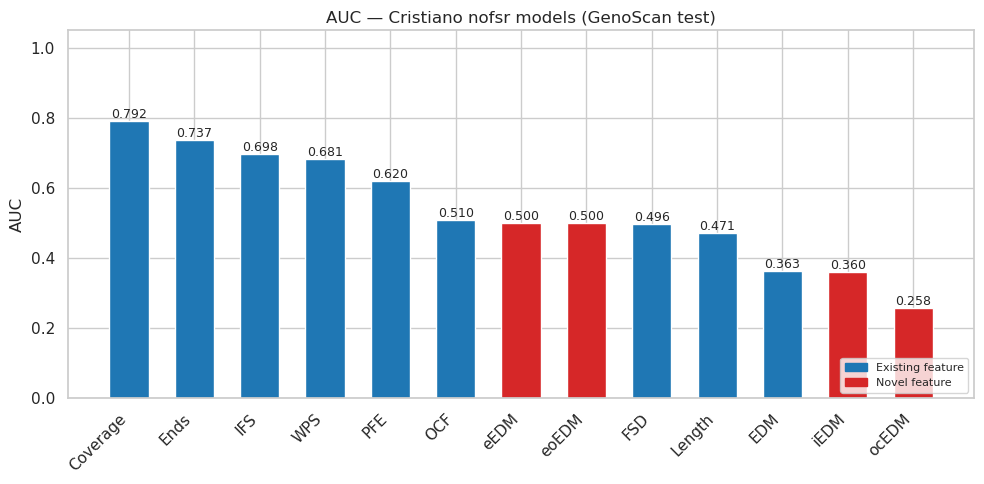

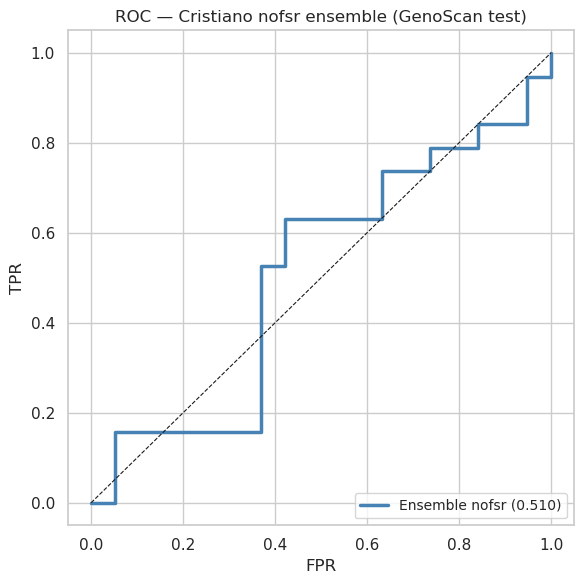

In [32]:
# D nofsr — GenoScan: per-feature ROC + nofsr ensemble ROC
fig, ax = plt.subplots(figsize=(8, 7))
sns.set_theme(style="whitegrid")
for d in cr_gs_roc:
    ax.plot(d['fpr'], d['tpr'], color=feat_color(d['name']),
            label=f"{d['name']} ({d['auc']:.3f})", linewidth=1.5)
ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('ROC — Cristiano nofsr models (GenoScan test)')
ax.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.savefig("scripts/analysis/figures/D_nofsr_roc_gs.png", bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
sns.set_theme(style="whitegrid")
ax.bar(range(len(names_gs)), aucs_gs, color=[is_new_color(n) for n in names_gs], width=0.6)
ax.set_xticks(range(len(names_gs))); ax.set_xticklabels(names_gs, rotation=45, ha='right')
ax.set_ylim(0, 1.05); ax.set_ylabel('AUC')
ax.set_title('AUC — Cristiano nofsr models (GenoScan test)')
ax.legend(handles=[Patch(color='#1f77b4', label='Existing feature'),
                   Patch(color='#d62728', label='Novel feature')],
          loc='lower right', fontsize=8)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.3f}',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig("scripts/analysis/figures/D_nofsr_auc_gs.png", bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(6, 6))
sns.set_theme(style="whitegrid")
ax.plot(nofsr_gs_fpr, nofsr_gs_tpr, color='steelblue', linewidth=2.5,
        label=f"Ensemble nofsr ({nofsr_gs_auc:.3f})")
ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('ROC — Cristiano nofsr ensemble (GenoScan test)')
ax.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.savefig("scripts/analysis/figures/D_nofsr_ens_roc_gs.png", bbox_inches='tight')
plt.show()


## D (LY-trained) — LY CV and external test
Note: LY cohort contains only CRC + controls — no cancer-type grid.

In [33]:
ly_cv_dir = "data/matrix_internal_ly_train/svm_by_feature/svm_linear_pca150.0_gc_mapq30/cv/"
ly_ly_dir = "data/matrix_internal_ly_train/svm_by_feature/svm_linear_pca150.0_gc_mapq30/test/prevelynch_test/"

ly_cv_roc = load_roc_data(ly_cv_dir, suffix='_cv_probs.csv')
ly_ly_roc = load_roc_data(ly_ly_dir)
ly_gs_roc = load_roc_data(gs_test_dir)

names_ly_cv = [d['name'] for d in ly_cv_roc]; aucs_ly_cv = [d['auc'] for d in ly_cv_roc]
names_ly_ly = [d['name'] for d in ly_ly_roc]; aucs_ly_ly = [d['auc'] for d in ly_ly_roc]
names_ly_gs = [d['name'] for d in ly_gs_roc]; aucs_ly_gs = [d['auc'] for d in ly_gs_roc]


Missing: ['pfe', 'coverage', 'ends', 'ocf', 'wps']
Missing: ['fsr']
Missing: ['fsr']


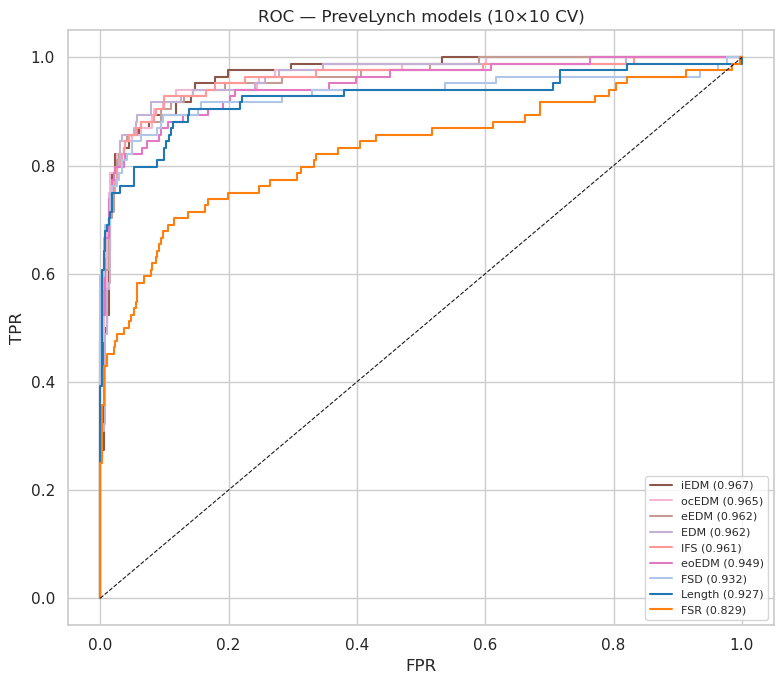

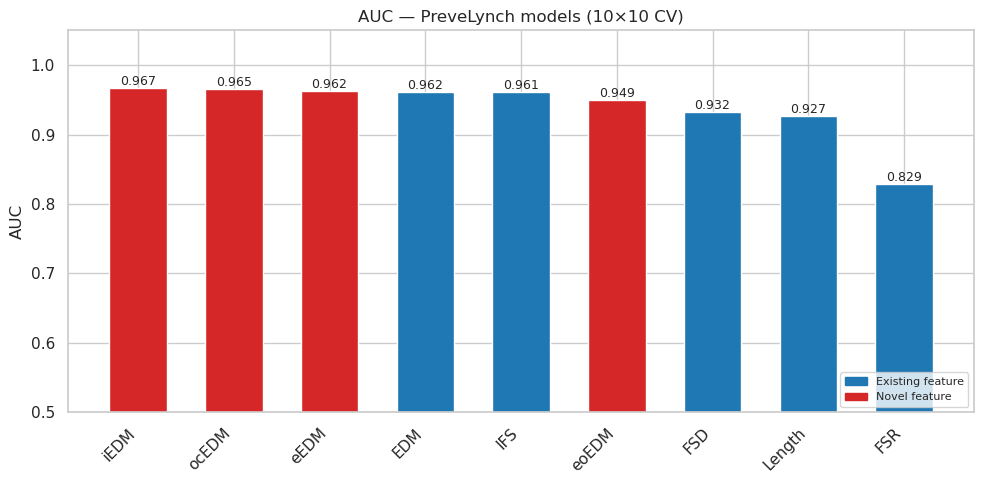

In [34]:
# D19 — PreveLynch CV ROC + AUC bars
fig, ax = plt.subplots(figsize=(8, 7))
sns.set_theme(style="whitegrid")
for d in ly_cv_roc:
    ax.plot(d['fpr'], d['tpr'], color=feat_color(d['name']),
            label=f"{d['name']} ({d['auc']:.3f})", linewidth=1.5)
ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('ROC — PreveLynch models (10×10 CV)')
ax.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.savefig("scripts/analysis/figures/D19_roc_ly_cv.png", bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
sns.set_theme(style="whitegrid")
ax.bar(range(len(names_ly_cv)), aucs_ly_cv,
        color=[is_new_color(n) for n in names_ly_cv], width=0.6)
ax.set_xticks(range(len(names_ly_cv))); ax.set_xticklabels(names_ly_cv, rotation=45, ha='right')
ax.set_ylim(0.5, 1.05); ax.set_ylabel('AUC')
ax.set_title('AUC — PreveLynch models (10×10 CV)')
ax.legend(handles=[Patch(color='#1f77b4', label='Existing feature'),
                   Patch(color='#d62728', label='Novel feature')],
          loc='lower right', fontsize=8)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.3f}',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig("scripts/analysis/figures/D19b_auc_ly_cv.png", bbox_inches='tight')
plt.show()


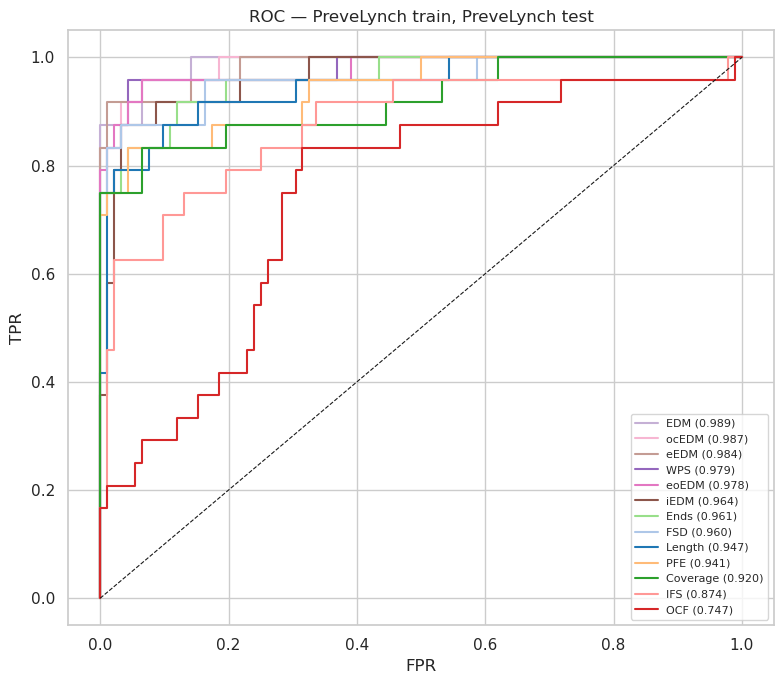

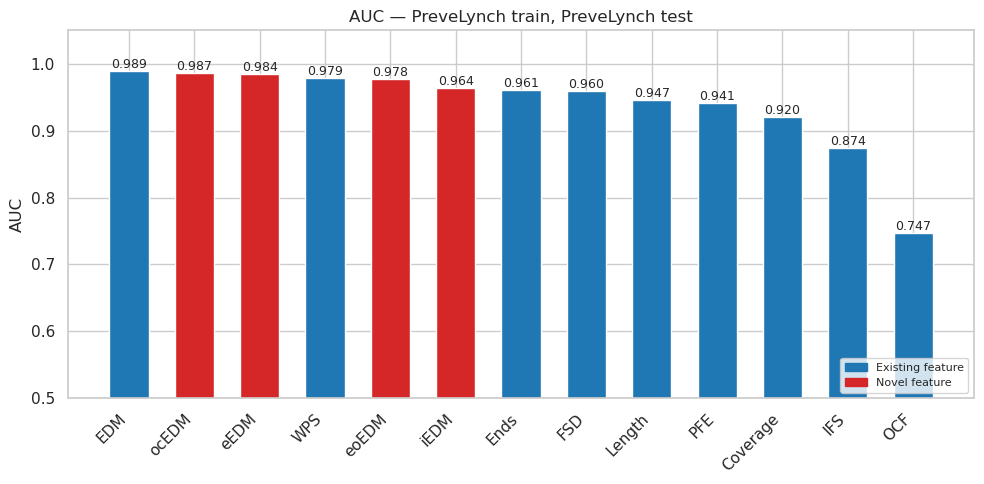

In [35]:
# D20 — PreveLynch train, PreveLynch test ROC + AUC bars
fig, ax = plt.subplots(figsize=(8, 7))
sns.set_theme(style="whitegrid")
for d in ly_ly_roc:
    ax.plot(d['fpr'], d['tpr'], color=feat_color(d['name']),
            label=f"{d['name']} ({d['auc']:.3f})", linewidth=1.5)
ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('ROC — PreveLynch train, PreveLynch test')
ax.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.savefig("scripts/analysis/figures/D20_roc_ly_ly.png", bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
sns.set_theme(style="whitegrid")
ax.bar(range(len(names_ly_ly)), aucs_ly_ly,
        color=[is_new_color(n) for n in names_ly_ly], width=0.6)
ax.set_xticks(range(len(names_ly_ly))); ax.set_xticklabels(names_ly_ly, rotation=45, ha='right')
ax.set_ylim(0.5, 1.05); ax.set_ylabel('AUC')
ax.set_title('AUC — PreveLynch train, PreveLynch test')
ax.legend(handles=[Patch(color='#1f77b4', label='Existing feature'),
                   Patch(color='#d62728', label='Novel feature')],
          loc='lower right', fontsize=8)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.3f}',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig("scripts/analysis/figures/D20b_auc_ly_ly.png", bbox_inches='tight')
plt.show()


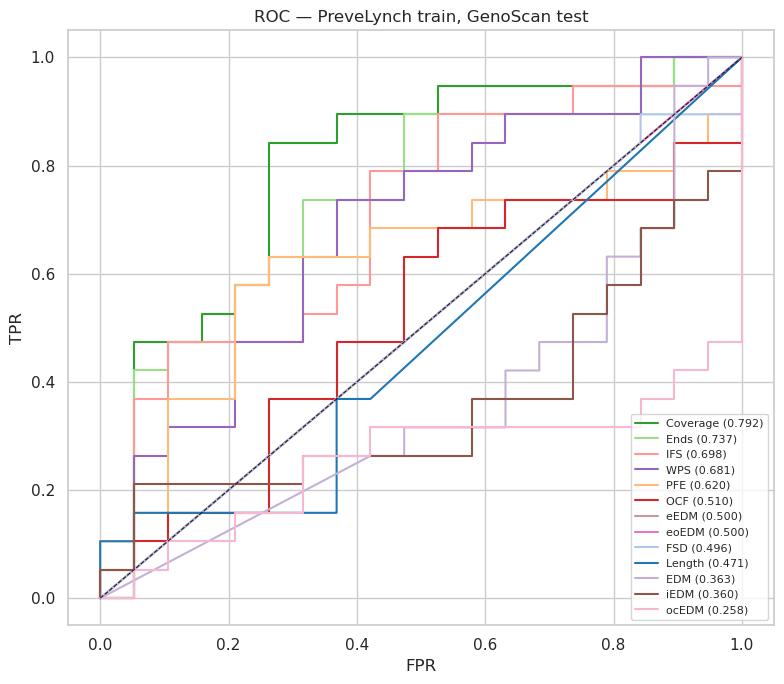

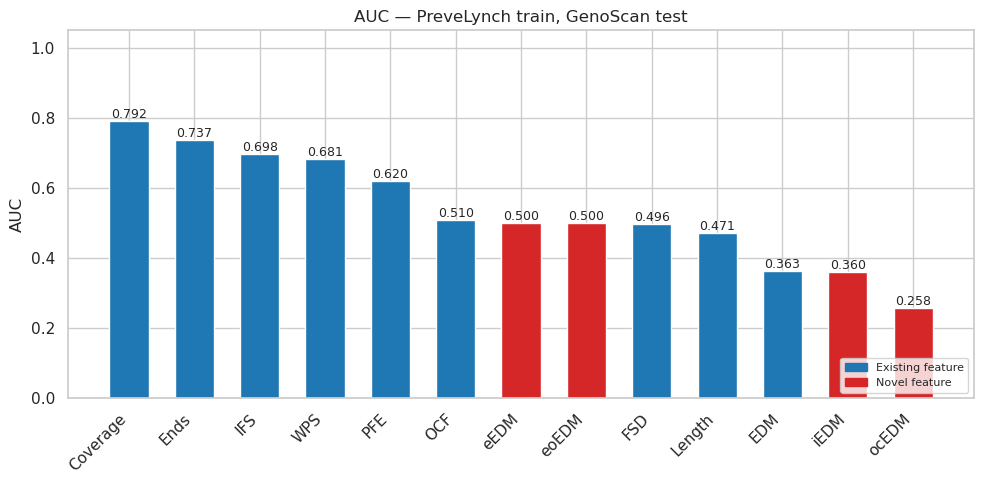

In [36]:
# D21 — PreveLynch train, GenoScan test ROC + AUC bars
fig, ax = plt.subplots(figsize=(8, 7))
sns.set_theme(style="whitegrid")
for d in ly_gs_roc:
    ax.plot(d['fpr'], d['tpr'], color=feat_color(d['name']),
            label=f"{d['name']} ({d['auc']:.3f})", linewidth=1.5)
ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('ROC — PreveLynch train, GenoScan test')
ax.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.savefig("scripts/analysis/figures/D21_roc_ly_gs.png", bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
sns.set_theme(style="whitegrid")
ax.bar(range(len(names_ly_gs)), aucs_ly_gs,
        color=[is_new_color(n) for n in names_ly_gs], width=0.6)
ax.set_xticks(range(len(names_ly_gs))); ax.set_xticklabels(names_ly_gs, rotation=45, ha='right')
ax.set_ylim(0, 1.05); ax.set_ylabel('AUC')
ax.set_title('AUC — PreveLynch train, GenoScan test')
ax.legend(handles=[Patch(color='#1f77b4', label='Existing feature'),
                   Patch(color='#d62728', label='Novel feature')],
          loc='lower right', fontsize=8)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.3f}',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig("scripts/analysis/figures/D21b_auc_ly_gs.png", bbox_inches='tight')
plt.show()

## D (CRC-trained) — CRC CV and external test
Note: CRC cohort contains only Colorectal cancer + controls.

In [37]:
crc_cv_dir  = "data/matrix_crc/svm_by_feature/svm_linear_pca150.0_gc_mapq30/cv/"
crc_ly_dir  = "data/matrix_crc/svm_by_feature/svm_linear_pca150.0_gc_mapq30/test/prevelynch_test/"
crc_gs_dir  = "data/matrix_crc/svm_by_feature/svm_linear_pca150.0_gc_mapq30/test/genoscan/"
crc_manifest = pd.read_csv("data/manifest/Cristiano_metadata_crc.csv")[['sample_id', 'disease', 'stage']]

crc_cv_roc = load_roc_data(crc_cv_dir, suffix='_cv_probs.csv')
crc_ly_roc = load_roc_data(crc_ly_dir)
crc_gs_roc = load_roc_data(crc_gs_dir)

names_crc_cv = [d['name'] for d in crc_cv_roc]; aucs_crc_cv = [d['auc'] for d in crc_cv_roc]
names_crc_ly = [d['name'] for d in crc_ly_roc]; aucs_crc_ly = [d['auc'] for d in crc_ly_roc]
names_crc_gs = [d['name'] for d in crc_gs_roc]; aucs_crc_gs = [d['auc'] for d in crc_gs_roc]


Missing: ['fsr', 'pfe', 'coverage', 'wps']
Missing: ['fsr']
Missing: ['fsr']


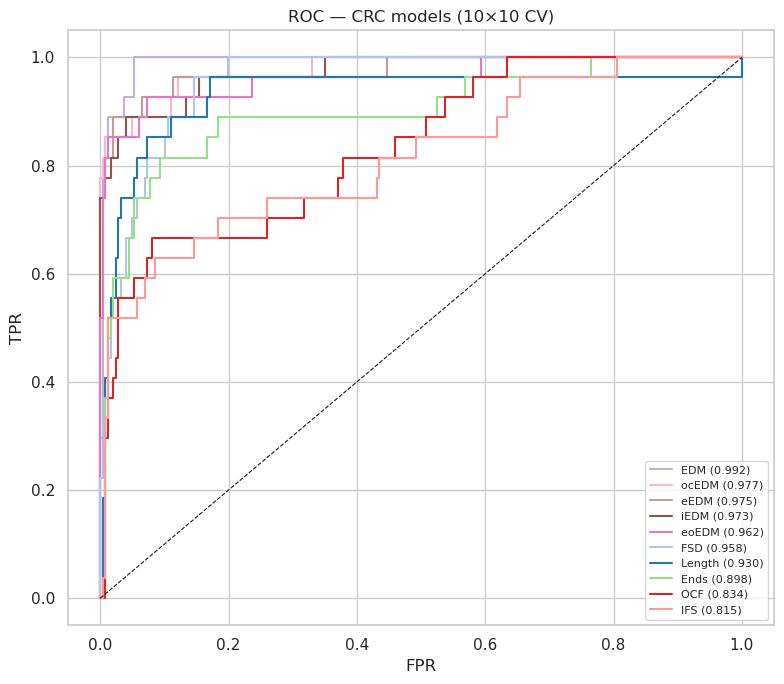

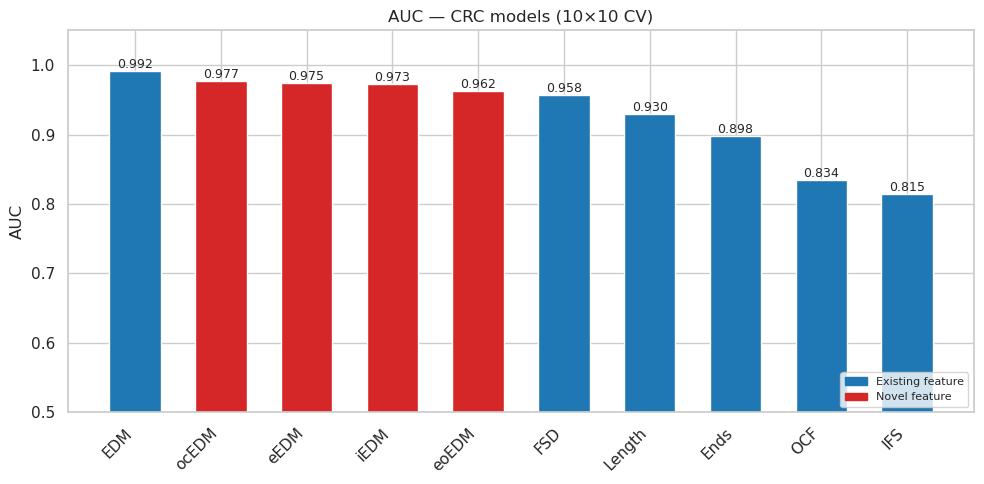

In [38]:
# D16 — CRC CV ROC + AUC bars
fig, ax = plt.subplots(figsize=(8, 7))
sns.set_theme(style="whitegrid")
for d in crc_cv_roc:
    ax.plot(d['fpr'], d['tpr'], color=feat_color(d['name']),
            label=f"{d['name']} ({d['auc']:.3f})", linewidth=1.5)
ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('ROC — CRC models (10×10 CV)')
ax.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.savefig("scripts/analysis/figures/D16_roc_crc_cv.png", bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
sns.set_theme(style="whitegrid")
ax.bar(range(len(names_crc_cv)), aucs_crc_cv,
        color=[is_new_color(n) for n in names_crc_cv], width=0.6)
ax.set_xticks(range(len(names_crc_cv))); ax.set_xticklabels(names_crc_cv, rotation=45, ha='right')
ax.set_ylim(0.5, 1.05); ax.set_ylabel('AUC')
ax.set_title('AUC — CRC models (10×10 CV)')
ax.legend(handles=[Patch(color='#1f77b4', label='Existing feature'),
                   Patch(color='#d62728', label='Novel feature')],
          loc='lower right', fontsize=8)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.3f}',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig("scripts/analysis/figures/D16b_auc_crc_cv.png", bbox_inches='tight')
plt.show()


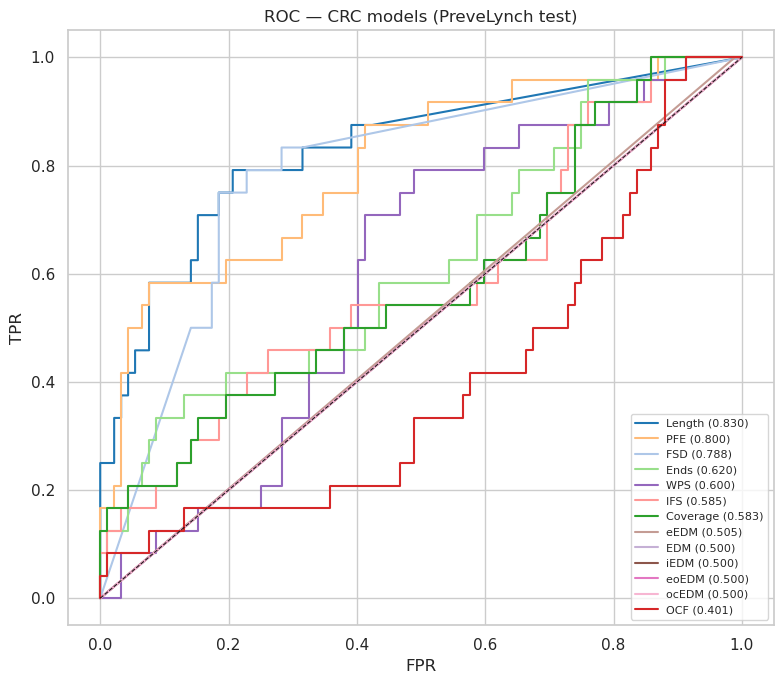

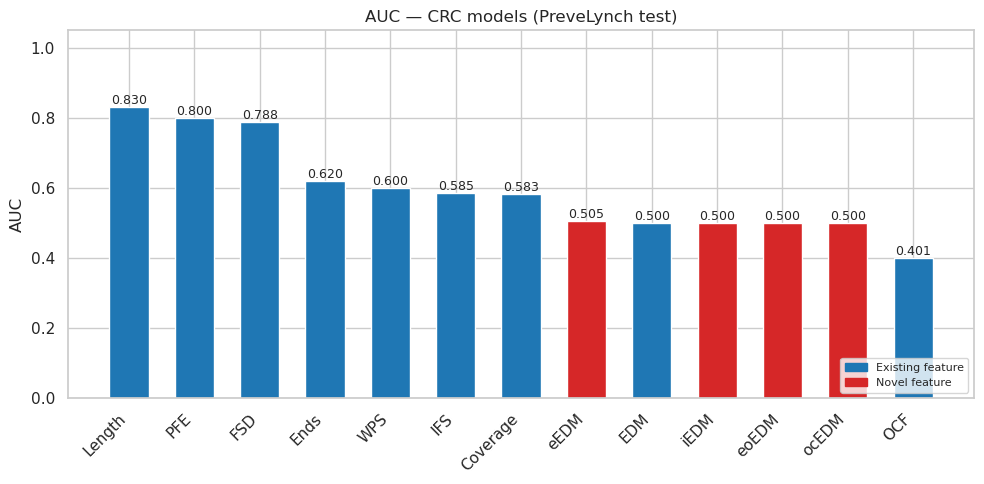

In [39]:
# D17 — CRC models → PreveLynch ROC + AUC bars
fig, ax = plt.subplots(figsize=(8, 7))
sns.set_theme(style="whitegrid")
for d in crc_ly_roc:
    ax.plot(d['fpr'], d['tpr'], color=feat_color(d['name']),
            label=f"{d['name']} ({d['auc']:.3f})", linewidth=1.5)
ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('ROC — CRC models (PreveLynch test)')
ax.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.savefig("scripts/analysis/figures/D17_roc_crc_ly.png", bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
sns.set_theme(style="whitegrid")
ax.bar(range(len(names_crc_ly)), aucs_crc_ly,
        color=[is_new_color(n) for n in names_crc_ly], width=0.6)
ax.set_xticks(range(len(names_crc_ly))); ax.set_xticklabels(names_crc_ly, rotation=45, ha='right')
ax.set_ylim(0, 1.05); ax.set_ylabel('AUC')
ax.set_title('AUC — CRC models (PreveLynch test)')
ax.legend(handles=[Patch(color='#1f77b4', label='Existing feature'),
                   Patch(color='#d62728', label='Novel feature')],
          loc='lower right', fontsize=8)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.3f}',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig("scripts/analysis/figures/D17b_auc_crc_ly.png", bbox_inches='tight')
plt.show()


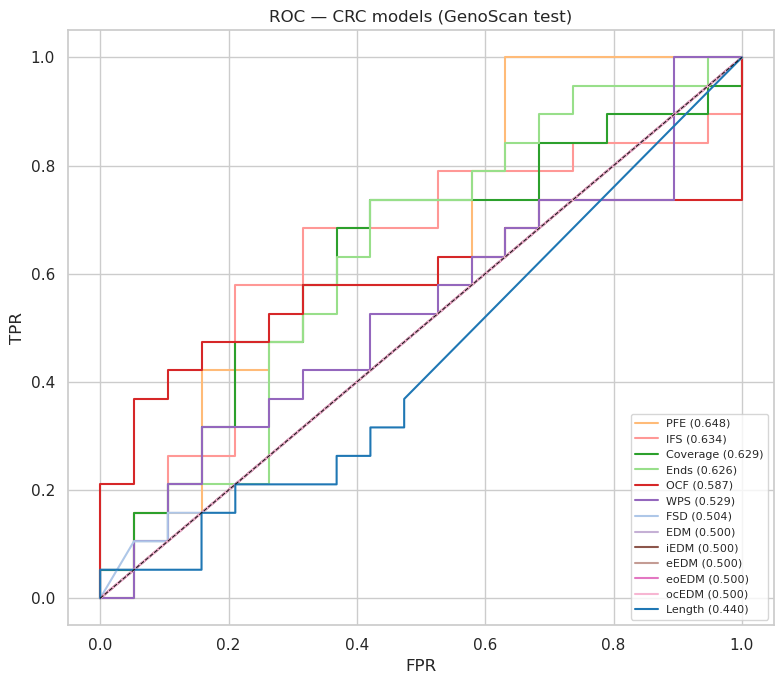

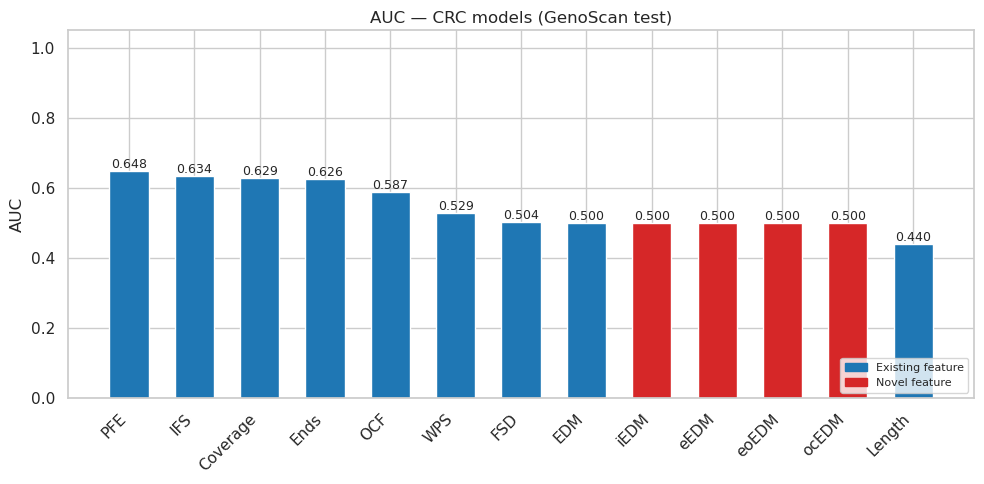

In [40]:
# D18 — CRC models → GenoScan ROC + AUC bars
fig, ax = plt.subplots(figsize=(8, 7))
sns.set_theme(style="whitegrid")
for d in crc_gs_roc:
    ax.plot(d['fpr'], d['tpr'], color=feat_color(d['name']),
            label=f"{d['name']} ({d['auc']:.3f})", linewidth=1.5)
ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('ROC — CRC models (GenoScan test)')
ax.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.savefig("scripts/analysis/figures/D18_roc_crc_gs.png", bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
sns.set_theme(style="whitegrid")
ax.bar(range(len(names_crc_gs)), aucs_crc_gs,
        color=[is_new_color(n) for n in names_crc_gs], width=0.6)
ax.set_xticks(range(len(names_crc_gs))); ax.set_xticklabels(names_crc_gs, rotation=45, ha='right')
ax.set_ylim(0, 1.05); ax.set_ylabel('AUC')
ax.set_title('AUC — CRC models (GenoScan test)')
ax.legend(handles=[Patch(color='#1f77b4', label='Existing feature'),
                   Patch(color='#d62728', label='Novel feature')],
          loc='lower right', fontsize=8)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.3f}',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig("scripts/analysis/figures/D18b_auc_crc_gs.png", bbox_inches='tight')
plt.show()


## E — Summary tables

In [41]:
roc_dict_cristiano = {
    'Cristiano CV':   cv_roc,
    'Cristiano train, LY test':   cr_ly_roc,
    'Cristiano train, GS test':   cr_gs_roc,

}
roc_dict_ly = {
    'LY CV':       ly_cv_roc,
    'LY train, LY test':       ly_ly_roc,
    'LY train, GS test':       ly_gs_roc,
}
os.makedirs('scripts/analysis/tables', exist_ok=True)


In [42]:
# E — AUC summary table
auc_table_cristiano = build_auc_table(roc_dict_cristiano).round(4)
auc_table_cristiano.to_csv('scripts/analysis/tables/E_auc_summary_cristiano.csv')
auc_table_ly = build_auc_table(roc_dict_ly).round(4)
auc_table_ly.to_csv('scripts/analysis/tables/E_auc_summary_ly.csv')
display(auc_table_cristiano)
display(auc_table_ly)


,Cristiano CV,"Cristiano train, LY test","Cristiano train, GS test"
feature,,,
EDM,0.9675,0.6241,0.3629
ocEDM,0.9641,0.2260,0.2576
IFS,0.9604,0.8401,0.6981
Ends,0.9577,0.8990,0.7368
WPS,0.9576,0.9434,0.6814
PFE,0.9540,0.8961,0.6205
Coverage,0.9506,0.9103,0.7922
eEDM,0.9448,0.4085,0.5000
iEDM,0.9273,0.6676,0.3601


,LY CV,"LY train, LY test","LY train, GS test"
feature,,,
iEDM,0.9672,0.9642,0.3601
ocEDM,0.9649,0.9869,0.2576
eEDM,0.9619,0.9841,0.5000
EDM,0.9618,0.9887,0.3629
IFS,0.9614,0.8741,0.6981
eoEDM,0.9492,0.9778,0.5000
FSD,0.9320,0.9597,0.4958
Length,0.9268,0.9466,0.4709
FSR,0.8288,NaN,NaN


In [43]:
# E — Sensitivity at fixed specificity (95% and 85%)
sens_table_cristiano = build_sensitivity_table(roc_dict_cristiano, specificities=(0.95, 0.85)).round(4)
sens_table_cristiano.to_csv('scripts/analysis/tables/E_sensitivity_table_cristiano.csv')
display(sens_table_cristiano)
sens_table_ly = build_sensitivity_table(roc_dict_ly, specificities=(0.95, 0.85)).round(4)
sens_table_ly.to_csv('scripts/analysis/tables/E_sensitivity_table_ly.csv')
display(sens_table_ly)


,Cristiano CV_sens95,Cristiano CV_sens85,"Cristiano train, LY test_sens95","Cristiano train, LY test_sens85","Cristiano train, GS test_sens95","Cristiano train, GS test_sens85"
feature,,,,,,
EDM,0.9155,0.9577,0.0000,0.0000,0.0000,0.0000
ocEDM,0.8216,0.9437,0.0000,0.0000,0.0000,0.1053
IFS,0.8404,0.9202,0.5417,0.6667,0.0000,0.4737
Ends,0.8685,0.9202,0.5833,0.8750,0.0000,0.4737
WPS,0.8592,0.9202,0.7500,0.8750,0.0000,0.3158
PFE,0.8404,0.8873,0.5833,0.8333,0.1053,0.3684
Coverage,0.8498,0.9108,0.7083,0.7917,0.0000,0.4737
eEDM,0.7793,0.8920,0.0000,0.0000,0.0000,0.0000
iEDM,0.7324,0.8545,0.1250,0.4167,0.0526,0.2105


,LY CV_sens95,LY CV_sens85,"LY train, LY test_sens95","LY train, LY test_sens85","LY train, GS test_sens95","LY train, GS test_sens85"
feature,,,,,,
iEDM,0.8571,0.9524,0.8750,0.9167,0.0526,0.2105
ocEDM,0.8571,0.9405,0.9167,0.9583,0.0000,0.1053
eEDM,0.8571,0.9286,0.9167,0.9583,0.0000,0.0000
EDM,0.8571,0.9405,0.8750,1.0000,0.0000,0.0000
IFS,0.8571,0.9286,0.6250,0.7500,0.0000,0.4737
eoEDM,0.8214,0.8929,0.9167,0.9583,0.0000,0.0000
FSD,0.8452,0.8929,0.8750,0.8750,0.0000,0.0000
Length,0.7619,0.9048,0.7917,0.8750,0.1053,0.1579
FSR,0.5238,0.7143,NaN,NaN,NaN,NaN


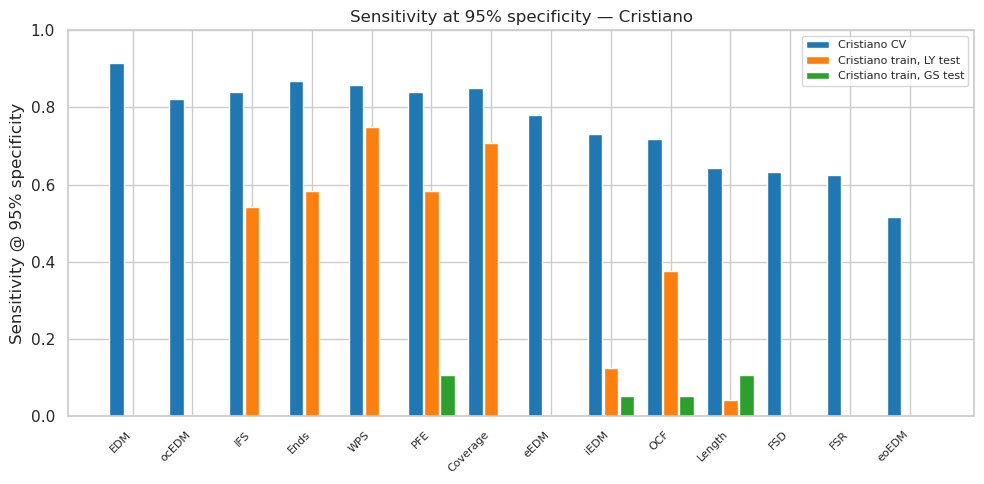

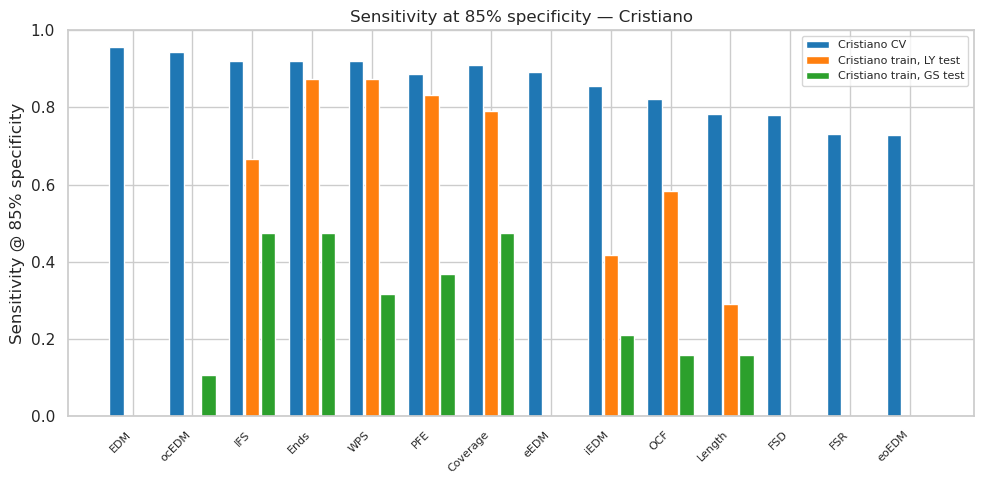

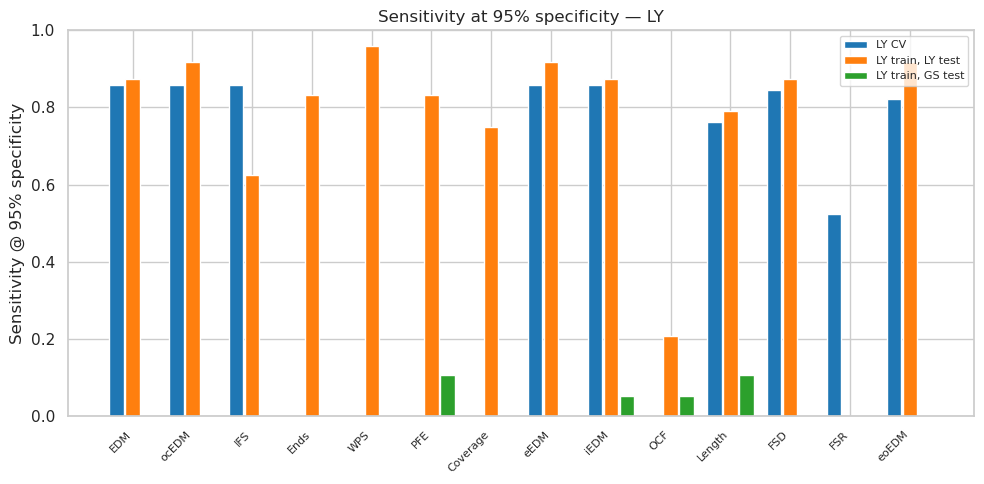

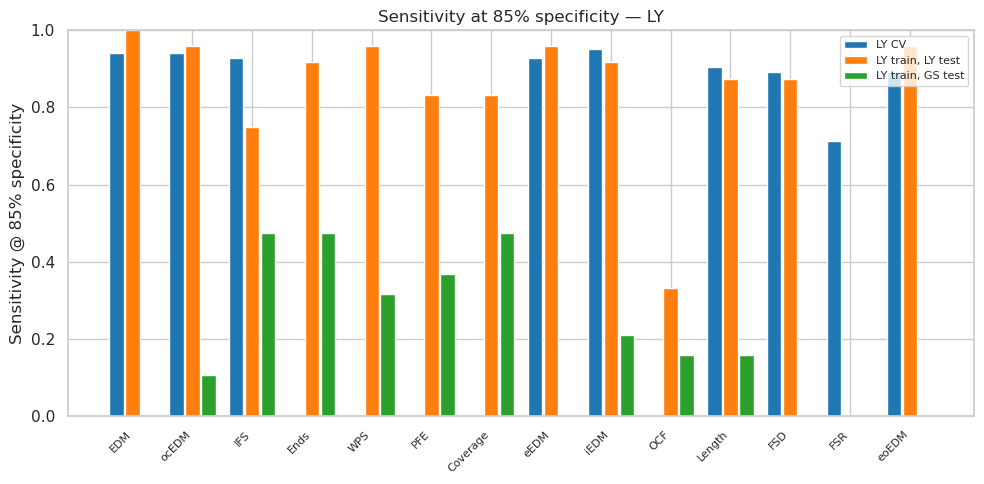

In [44]:
feat_order_e = [d['name'] for d in cv_roc]  # AUC desc order
specs = [95, 85]

for group_name, sens_table, roc_dict in [
    ('Cristiano', sens_table_cristiano, roc_dict_cristiano),
    ('LY',        sens_table_ly,        roc_dict_ly),
]:
    conditions = list(roc_dict.keys())
    cond_colors = dict(zip(conditions, sns.color_palette('tab10', len(conditions))))
    avail_feats = [f for f in feat_order_e if f in sens_table.index]
    x = np.arange(len(avail_feats))
    width = 0.8 / len(conditions)

    for spec in specs:
        cols = [f"{cond}_sens{spec}" for cond in conditions]
        plot_df = sens_table.loc[avail_feats, cols].copy()
        plot_df.columns = conditions

        fig, ax = plt.subplots(figsize=(10, 5))
        for k, cond in enumerate(conditions):
            offset = (k - (len(conditions) - 1) / 2) * width
            ax.bar(x + offset, plot_df[cond], width=width * 0.9,
                   color=cond_colors[cond], label=cond)
        ax.set_xticks(x)
        ax.set_xticklabels(avail_feats, rotation=45, ha='right', fontsize=8)
        ax.set_ylim(0, 1)
        ax.set_ylabel(f'Sensitivity @ {spec}% specificity')
        ax.set_title(f'Sensitivity at {spec}% specificity — {group_name}')
        ax.axhline(0, color='black', linewidth=0.5)
        ax.legend(fontsize=8, loc='upper right')
        plt.tight_layout()
        fname = f'scripts/analysis/figures/E_sensitivity_{group_name.lower()}_spec{spec}.png'
        plt.savefig(fname, bbox_inches='tight')
        plt.show()


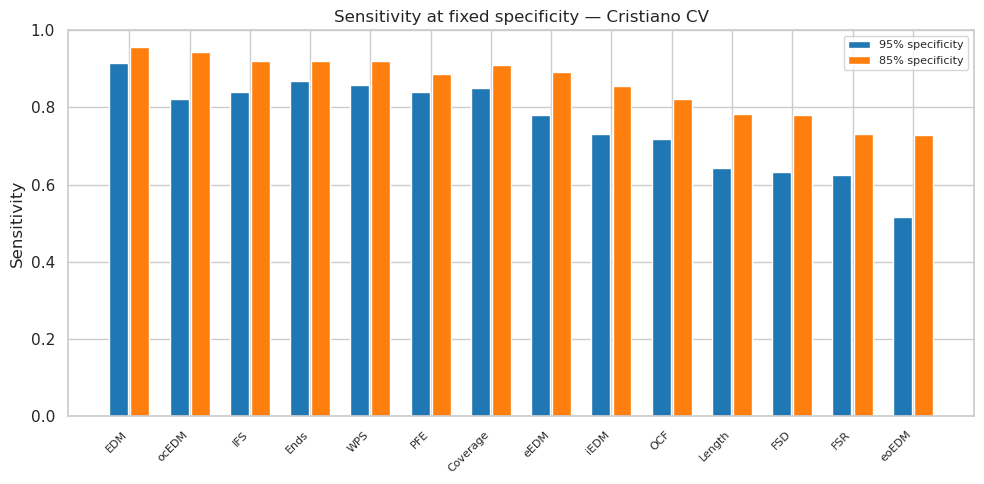

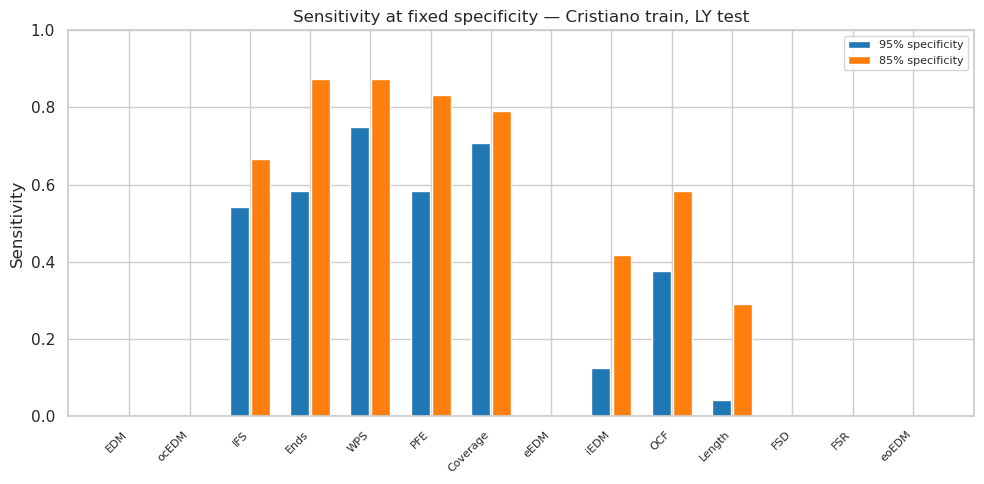

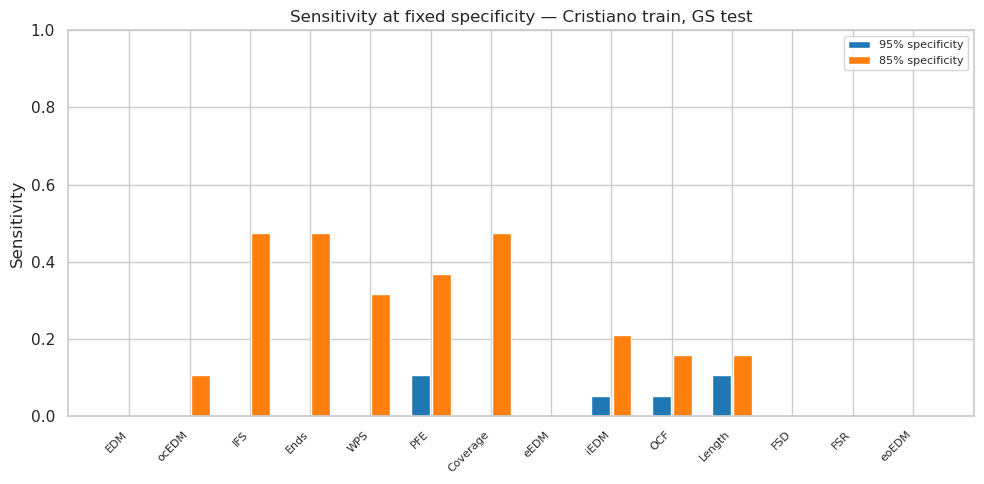

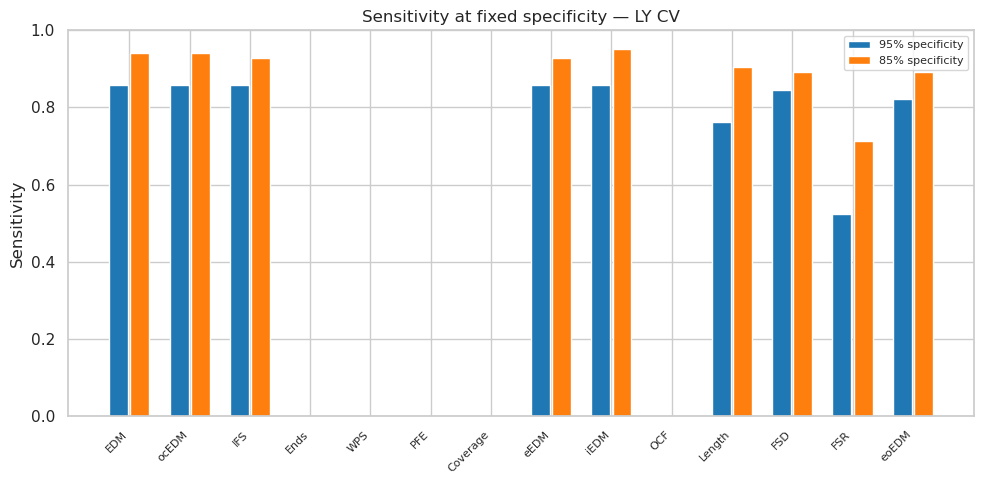

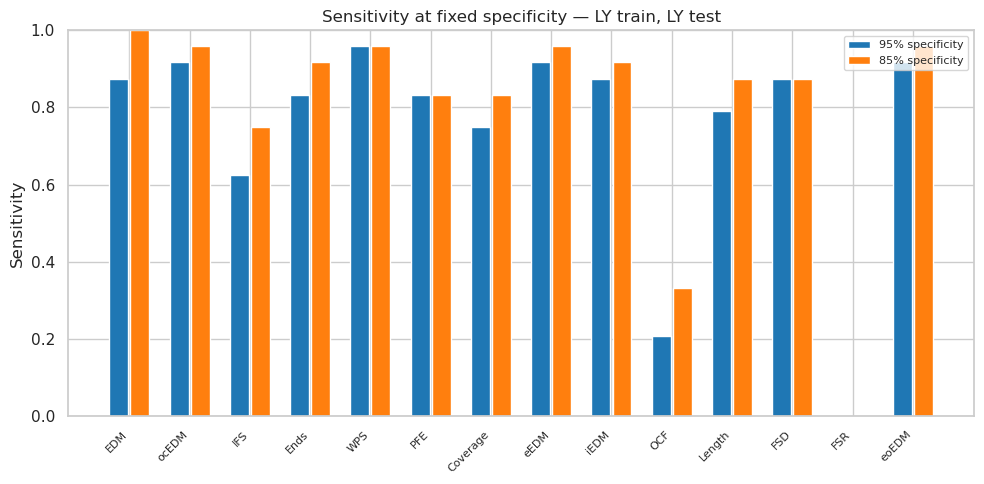

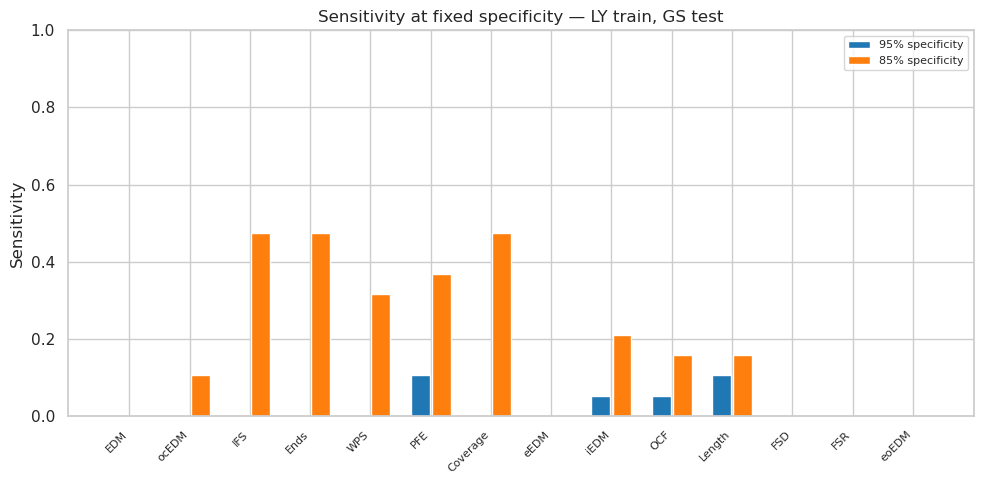

In [45]:
spec_colors = {95: '#1f77b4', 85: '#ff7f0e'}
width = 0.35

for group_name, sens_table, roc_dict in [
    ('Cristiano', sens_table_cristiano, roc_dict_cristiano),
    ('LY',        sens_table_ly,        roc_dict_ly),
]:
    avail_feats = [f for f in feat_order_e if f in sens_table.index]
    x = np.arange(len(avail_feats))

    for cond in roc_dict.keys():
        fig, ax = plt.subplots(figsize=(10, 5))
        for k, spec in enumerate([95, 85]):
            col = f"{cond}_sens{spec}"
            offset = (k - 0.5) * width
            ax.bar(x + offset, sens_table.loc[avail_feats, col],
                   width=width * 0.9, color=spec_colors[spec], label=f'{spec}% specificity')
        ax.set_xticks(x)
        ax.set_xticklabels(avail_feats, rotation=45, ha='right', fontsize=8)
        ax.set_ylim(0, 1)
        ax.set_ylabel('Sensitivity')
        ax.set_title(f'Sensitivity at fixed specificity — {cond}')
        ax.axhline(0, color='black', linewidth=0.5)
        ax.legend(fontsize=8, loc='upper right')
        plt.tight_layout()
        safe = cond.replace(' ', '_').replace(',', '').replace('→', '_')
        plt.savefig(f'scripts/analysis/figures/E_sensitivity_{safe}.png', bbox_inches='tight')
        plt.show()
